In [3]:
# Cell 1: Import Libraries and Constants
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
import requests
import logging
from sklearn.neighbors import BallTree  # Add this import

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Constants
PROXIMITY_THRESHOLD_METERS = 100
EARTH_RADIUS_METERS = 6371000
BARCELONA_PARKING_URL = "https://opendata-ajuntament.barcelona.cat/data/api/action/datastore_search"
PARKING_RESOURCE_ID = "1d6c814c-70ef-4147-aa16-a49ddb952f72"  # BSM parking facilities

# Barcelona geographical bounds
BARCELONA_BOUNDS = {
    'lat_min': 41.35,
    'lat_max': 41.45,
    'lon_min': 2.10,
    'lon_max': 2.23
}

ModuleNotFoundError: No module named 'plotly'

In [4]:
# Cell 2: Load BSM Data
def fetch_barcelona_parking_data():
    """Fetch parking facility data from Barcelona Open Data portal."""
    logger.info("Fetching Barcelona parking data...")
    
    try:
        params = {
            'resource_id': PARKING_RESOURCE_ID,
            'limit': 1000
        }
        
        response = requests.get(BARCELONA_PARKING_URL, params=params)
        response.raise_for_status()
        data = response.json()
        
        if not data.get('success'):
            raise ValueError("API request was not successful")
            
        records = data['result']['records']
        logger.info(f"Retrieved {len(records)} records from API")
        
        # Create DataFrame
        df = pd.DataFrame(records)
        
        # Parse coordinates
        def parse_coordinates(coord_str):
            if pd.isna(coord_str):
                return pd.Series({'lon': None, 'lat': None})
            try:
                coords = coord_str.split(',')
                if len(coords) >= 2:
                    return pd.Series({
                        'lon': float(coords[0]),
                        'lat': float(coords[1])
                    })
            except (ValueError, IndexError) as e:
                logger.warning(f"Error parsing coordinates: {coord_str} - {e}")
            return pd.Series({'lon': None, 'lat': None})
            
        coord_df = df['Coordenades'].apply(parse_coordinates)
        df = pd.concat([df, coord_df], axis=1)
        
        # Filter coordinates within Barcelona bounds
        df = df.dropna(subset=['lat', 'lon'])
        df = df[
            (df['lat'] >= BARCELONA_BOUNDS['lat_min']) &
            (df['lat'] <= BARCELONA_BOUNDS['lat_max']) &
            (df['lon'] >= BARCELONA_BOUNDS['lon_min']) &
            (df['lon'] <= BARCELONA_BOUNDS['lon_max'])
        ]
        
        return df
        
    except Exception as e:
        logger.error(f"Error fetching Barcelona parking data: {e}")
        raise


In [5]:
# Cell 3: Load SIU Data
SIU_DATA_PATH = '/Users/adrianiraeguialvear/OnSpot_Predictive_Model/data/feature_engineered_data.csv'
logger.info("Loading data files...")

# Load BSM data
bsm_data = fetch_barcelona_parking_data()
logger.info(f"Loaded BSM data with {len(bsm_data)} records")

# Load SIU data
siu_data = pd.read_csv(SIU_DATA_PATH)
logger.info(f"Loaded SIU data with {len(siu_data)} records")


NameError: name 'logger' is not defined

In [6]:
# Cell 1: Import Libraries and Constants
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
import requests
import logging
from sklearn.neighbors import BallTree  # Add this import

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Constants
PROXIMITY_THRESHOLD_METERS = 100
EARTH_RADIUS_METERS = 6371000
BARCELONA_PARKING_URL = "https://opendata-ajuntament.barcelona.cat/data/api/action/datastore_search"
PARKING_RESOURCE_ID = "1d6c814c-70ef-4147-aa16-a49ddb952f72"  # BSM parking facilities

# Barcelona geographical bounds
BARCELONA_BOUNDS = {
    'lat_min': 41.35,
    'lat_max': 41.45,
    'lon_min': 2.10,
    'lon_max': 2.23
}

# Cell 4: Merge Datasets
def merge_datasets(bsm_data, siu_data, proximity_threshold):
    """Match SIU points with nearest parking facilities."""
    logger.info("Starting dataset merge...")
    
    # Convert coordinates to radians
    bsm_coords = np.radians(bsm_data[['lat', 'lon']].values)
    siu_coords = np.radians(siu_data[['lat', 'lon']].values)

    # Build BallTree
    logger.info("Building BallTree for spatial matching...")
    tree = BallTree(bsm_coords, metric='haversine')

    # Find nearest neighbors
    logger.info("Finding nearest neighbors...")
    distances, indices = tree.query(siu_coords, k=1)

    # Convert distances to meters
    distances_meters = distances * EARTH_RADIUS_METERS

    # Filter matches within threshold
    matched_indices = distances_meters[:, 0] < proximity_threshold
    matched_bsm_indices = indices[matched_indices, 0]
    
    # Create matched dataframes
    matched_siu = siu_data[matched_indices].reset_index(drop=True)
    matched_bsm = bsm_data.iloc[matched_bsm_indices].reset_index(drop=True)
    
    # Add distance information
    matched_siu['distance_to_parking'] = distances_meters[matched_indices, 0]
    
    # Merge datasets
    merged_data = pd.concat([matched_siu, matched_bsm], axis=1)
    
    # Add match quality indicator
    merged_data['match_quality'] = pd.cut(
        merged_data['distance_to_parking'],
        bins=[0, 25, 50, 75, 100],
        labels=['Excellent', 'Good', 'Fair', 'Poor']
    )
    
    stats = {
        'total_matches': len(merged_data),
        'match_percentage': (len(merged_data) / len(siu_data)) * 100,
        'distance_stats': {
            'mean': float(distances_meters[matched_indices, 0].mean()),
            'min': float(distances_meters[matched_indices, 0].min()),
            'max': float(distances_meters[matched_indices, 0].max())
        },
        'quality_distribution': merged_data['match_quality'].value_counts().to_dict()
    }
    
    logger.info(f"Merge complete. Found {stats['total_matches']} matches " +
                f"({stats['match_percentage']:.2f}% of SIU points)")
    
    return merged_data, stats

# Perform matching
merged_data, stats = merge_datasets(bsm_data, siu_data, PROXIMITY_THRESHOLD_METERS)
print("\nMatching Statistics:")
print(json.dumps(stats, indent=2))

ModuleNotFoundError: No module named 'plotly'

Available columns:
['_id', 'id_tramo', 'tramo', 'tipo', 'tarifa', 'horario', 'lon', 'lat', 'time_slot', 'occupancy_level', 'datetime', 'hour', 'day_of_week', 'month', 'minute', 'slot_index', 'sin_time', 'cos_time', 'geo_cluster', 'zone_id_categorical', 'zone_id_encoded', 'occupancy_lag_5', 'occupancy_lag_10', 'occupancy_lag_15', 'tariff_numeric', 'regulated_hours', 'Tram', 'Descripció', 'Coordenades', '_id', 'lon', 'lat']

Data Distribution:

DateTime Range:
Start: 2025-01-31 07:00:00+00:00
End: 2025-02-01 06:55:00+00:00

Hourly Statistics:
     occupancy_level            
                mean count   std
hour                            
0               0.00  7128  0.00
1               0.00  7128  0.00
2               0.00  7128  0.00
3               0.00  7128  0.00
4               0.00  7128  0.00
5               0.00  7128  0.00
6               0.00  7128  0.00
7               0.13  7128  0.59
8               0.13  7128  0.59
9               0.14  7128  0.62
10              0.14  71

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


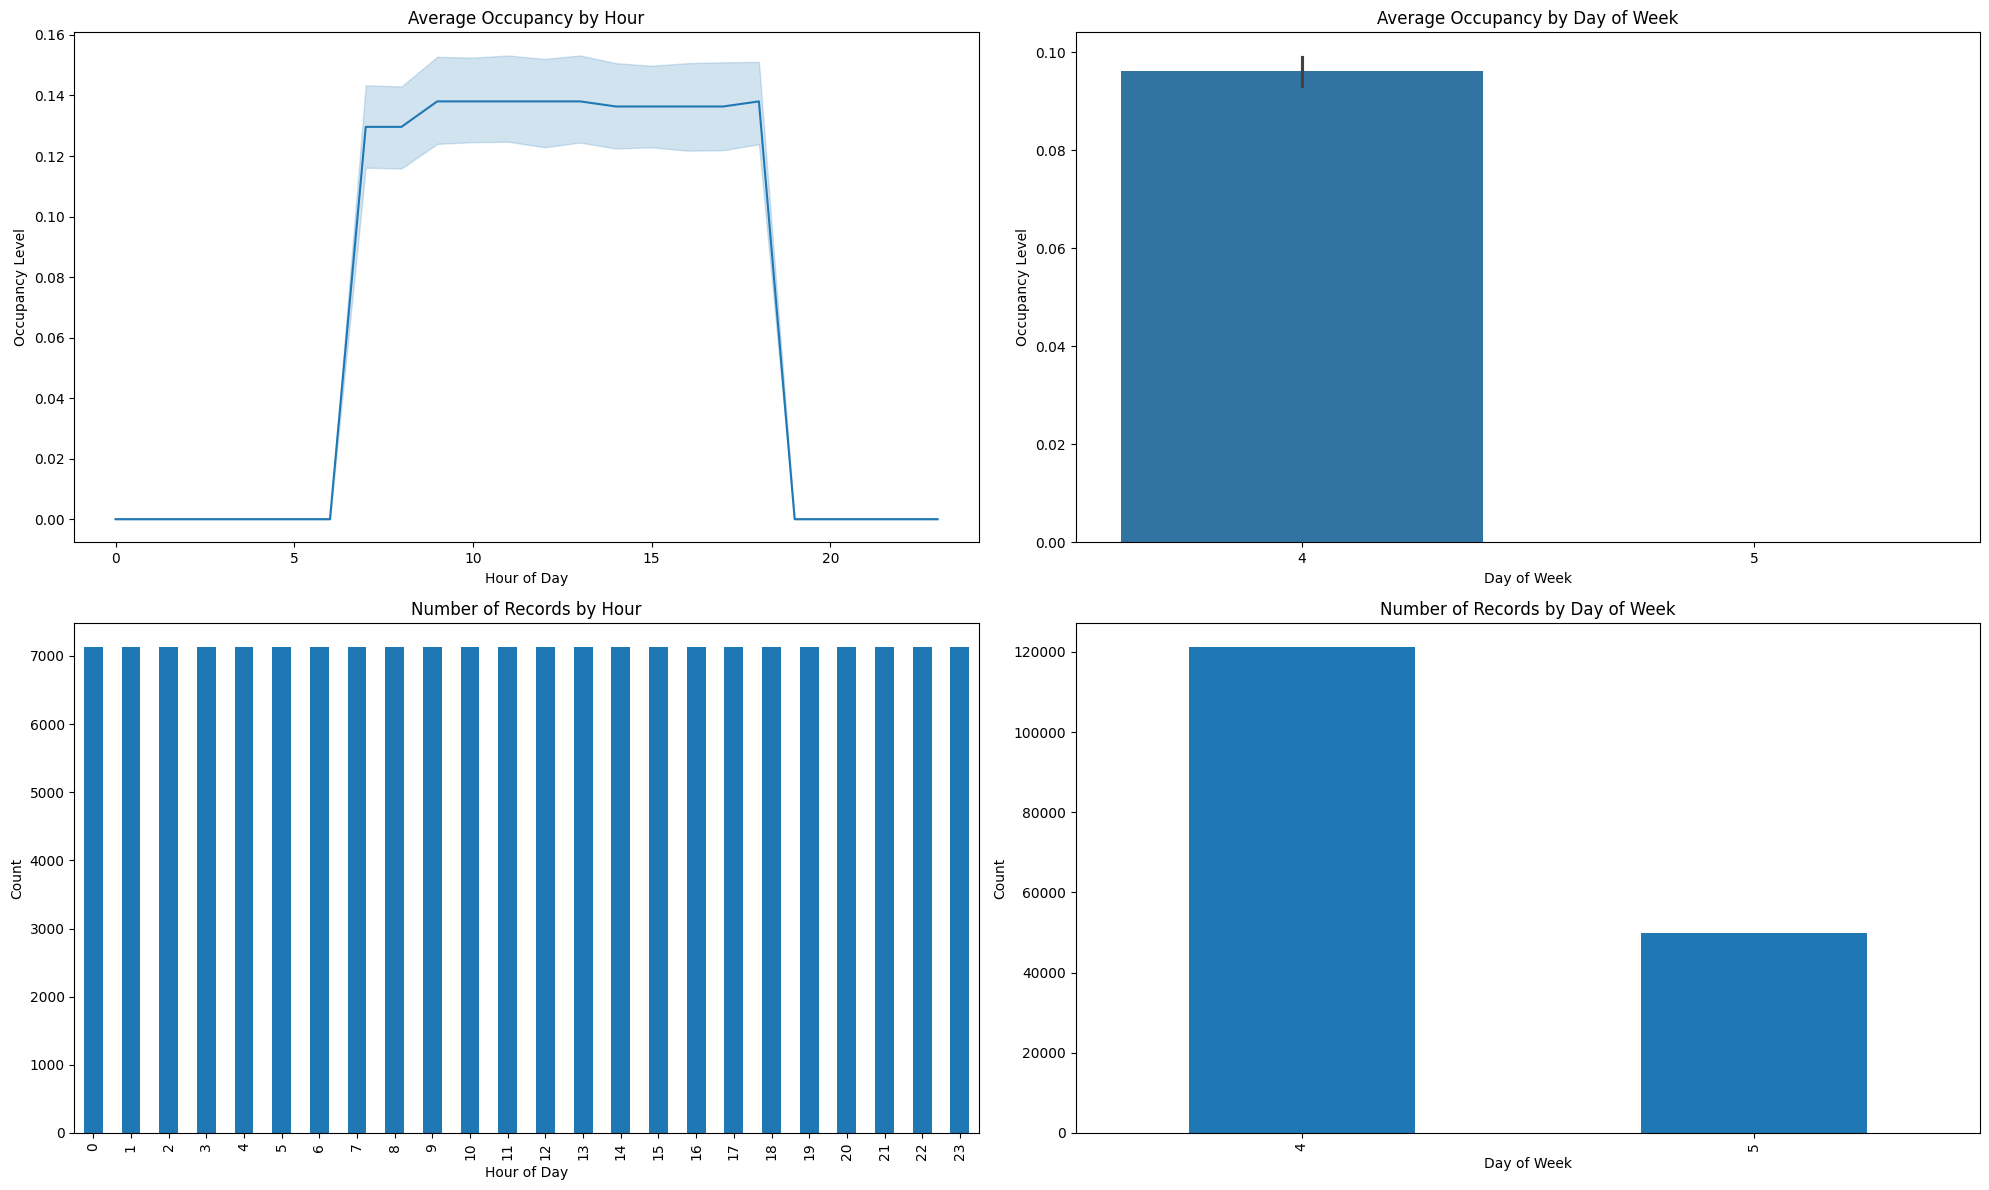

In [9]:
# Cell: Check Data Structure
print("Available columns:")
print(merged_data.columns.tolist())

# Cell: Modified Temporal Analysis
def analyze_temporal_patterns(merged_data):
    """Analyze matching patterns across different time periods."""
    # Print data distribution information
    print("\nData Distribution:")
    print("\nDateTime Range:")
    print(f"Start: {merged_data['datetime'].min()}")
    print(f"End: {merged_data['datetime'].max()}")
    
    # Hourly distribution
    hourly_stats = merged_data.groupby('hour').agg({
        'occupancy_level': ['mean', 'count', 'std']
    }).round(2)
    
    # Day of week patterns
    dow_stats = merged_data.groupby('day_of_week').agg({
        'occupancy_level': ['mean', 'count', 'std']
    }).round(2)
    
    # Print detailed statistics
    print("\nHourly Statistics:")
    print(hourly_stats)
    print("\nDay of Week Statistics:")
    print(dow_stats)
    
    # Visualizations
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))
    
    # 1. Hourly patterns - line plot
    sns.lineplot(data=merged_data, x='hour', y='occupancy_level', ax=ax1)
    ax1.set_title('Average Occupancy by Hour')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Occupancy Level')
    
    # 2. Daily patterns - bar plot
    sns.barplot(data=merged_data, x='day_of_week', y='occupancy_level', ax=ax2)
    ax2.set_title('Average Occupancy by Day of Week')
    ax2.set_xlabel('Day of Week')
    ax2.set_ylabel('Occupancy Level')
    
    # 3. Hourly count
    merged_data.groupby('hour').size().plot(kind='bar', ax=ax3)
    ax3.set_title('Number of Records by Hour')
    ax3.set_xlabel('Hour of Day')
    ax3.set_ylabel('Count')
    
    # 4. Daily count
    merged_data.groupby('day_of_week').size().plot(kind='bar', ax=ax4)
    ax4.set_title('Number of Records by Day of Week')
    ax4.set_xlabel('Day of Week')
    ax4.set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    return hourly_stats, dow_stats

# Run enhanced temporal analysis
hourly_stats, dow_stats = analyze_temporal_patterns(merged_data)


Summary Statistics by Type and Regulation:
                        mean    std  count  utilization_rate
tipo  regulated_hours                                       
BLAVA 0                0.050  0.373  18576             0.019
      1                0.577  1.160  18576             0.206
VERDA 0                0.000  0.000  66960             0.000
      1                0.000  0.000  66960             0.000

Peak Hours Analysis:

VERDA:
Peak hour: 8:00 (occupancy: 0.000)
Average occupancy during regulated hours: 0.000
Utilization rate: 0.0%

BLAVA:
Peak hour: 9:00 (occupancy: 0.636)
Average occupancy during regulated hours: 0.577
Utilization rate: 20.6%


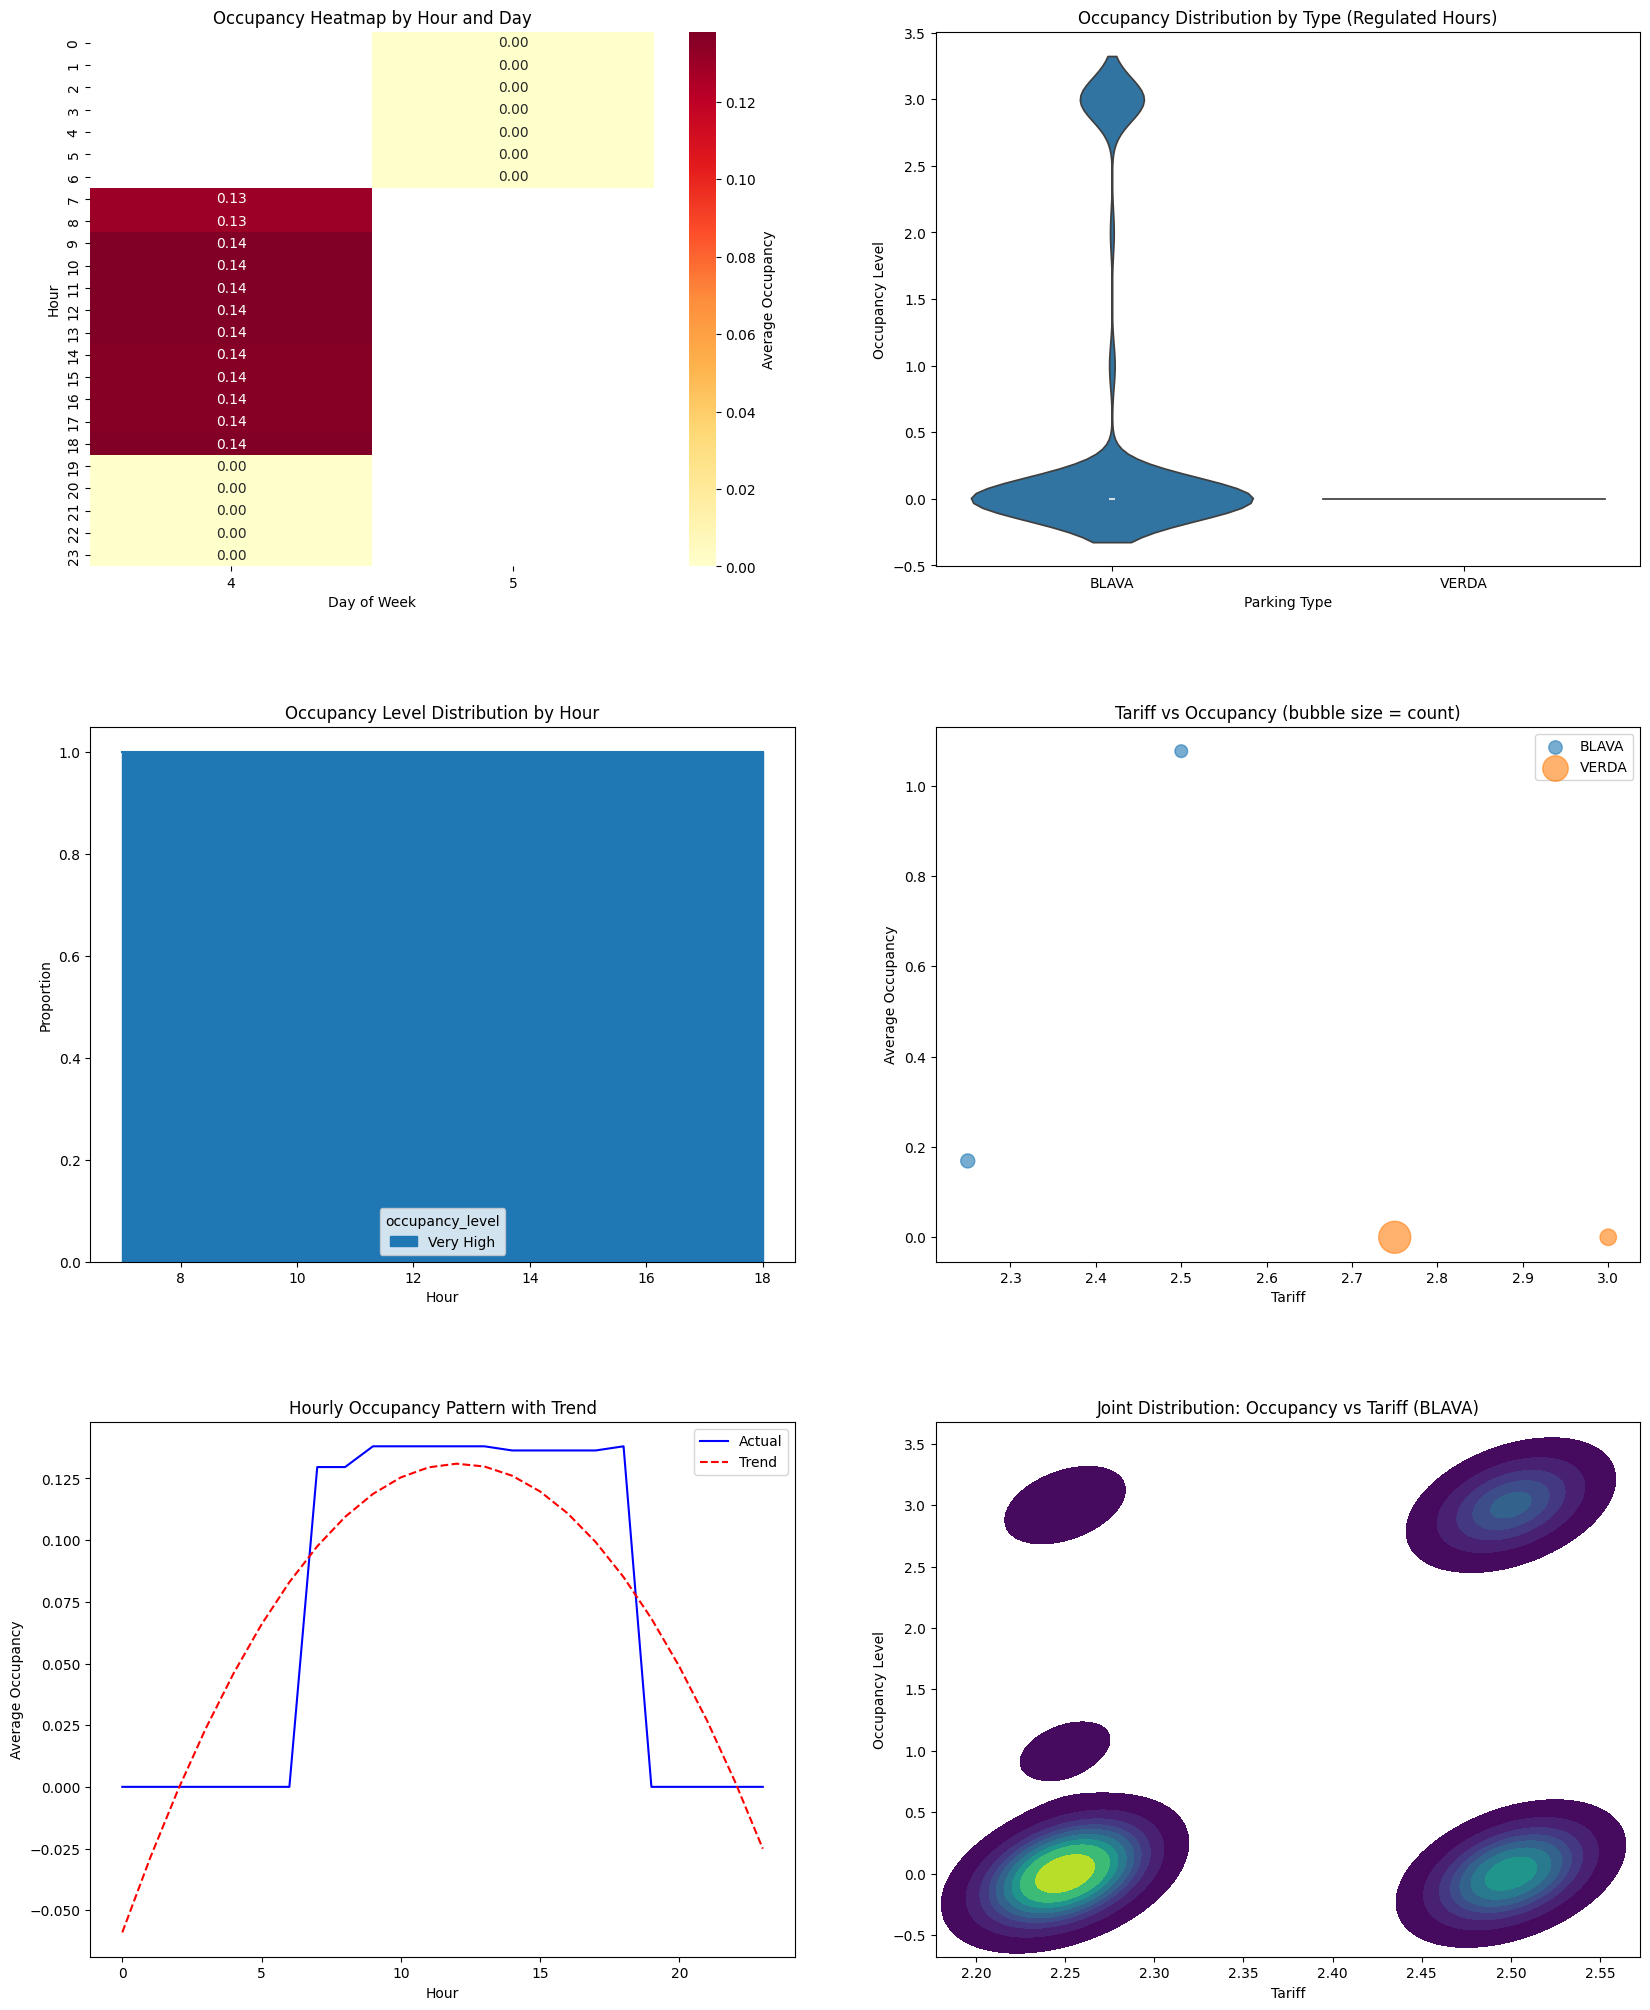

In [18]:
def analyze_temporal_patterns(merged_data):
    """Analyze temporal patterns with diverse visualization types."""
    
    # Create a figure with 6 subplots for different visualization types
    fig = plt.figure(figsize=(20, 25))
    gs = fig.add_gridspec(3, 2, hspace=0.3)
    
    # 1. Heatmap of Occupancy by Hour and Day
    ax1 = fig.add_subplot(gs[0, 0])
    pivot_data = merged_data.pivot_table(
        values='occupancy_level',
        index='hour',
        columns='day_of_week',
        aggfunc='mean'
    )
    sns.heatmap(pivot_data, cmap='YlOrRd', 
                annot=True, fmt='.2f', 
                cbar_kws={'label': 'Average Occupancy'},
                ax=ax1)
    ax1.set_title('Occupancy Heatmap by Hour and Day')
    ax1.set_xlabel('Day of Week')
    ax1.set_ylabel('Hour')
    
    # 2. Violin Plot of Occupancy Distribution by Type
    ax2 = fig.add_subplot(gs[0, 1])
    reg_data = merged_data[merged_data['regulated_hours'] == 1]
    sns.violinplot(data=reg_data, x='tipo', y='occupancy_level', ax=ax2)
    ax2.set_title('Occupancy Distribution by Type (Regulated Hours)')
    ax2.set_xlabel('Parking Type')
    ax2.set_ylabel('Occupancy Level')
    
    # 3. Stacked Area Chart of Occupancy Levels
    ax3 = fig.add_subplot(gs[1, 0])
    occupancy_bins = pd.cut(merged_data['occupancy_level'], 
                           bins=[0, 0.25, 0.5, 0.75, 1.0],
                           labels=['Low', 'Medium', 'High', 'Very High'])
    stacked_data = pd.crosstab(merged_data['hour'], occupancy_bins, normalize='index')
    stacked_data.plot(kind='area', stacked=True, ax=ax3)
    ax3.set_title('Occupancy Level Distribution by Hour')
    ax3.set_xlabel('Hour')
    ax3.set_ylabel('Proportion')
    
    # 4. Bubble Plot: Tariff vs Occupancy vs Count
    ax4 = fig.add_subplot(gs[1, 1])
    bubble_data = reg_data.groupby(['tariff_numeric', 'tipo'])['occupancy_level'].agg(['mean', 'count']).reset_index()
    for tipo in bubble_data['tipo'].unique():
        tipo_data = bubble_data[bubble_data['tipo'] == tipo]
        ax4.scatter(tipo_data['tariff_numeric'], tipo_data['mean'], 
                   s=tipo_data['count']/100, alpha=0.6, label=tipo)
    ax4.set_title('Tariff vs Occupancy (bubble size = count)')
    ax4.set_xlabel('Tariff')
    ax4.set_ylabel('Average Occupancy')
    ax4.legend()
    
    # 5. Time Series Decomposition
    ax5 = fig.add_subplot(gs[2, 0])
    hourly_occupancy = merged_data.groupby('hour')['occupancy_level'].mean()
    # Add trend line
    z = np.polyfit(hourly_occupancy.index, hourly_occupancy.values, 2)
    p = np.poly1d(z)
    ax5.plot(hourly_occupancy.index, hourly_occupancy.values, 'b-', label='Actual')
    ax5.plot(hourly_occupancy.index, p(hourly_occupancy.index), 'r--', label='Trend')
    ax5.set_title('Hourly Occupancy Pattern with Trend')
    ax5.set_xlabel('Hour')
    ax5.set_ylabel('Average Occupancy')
    ax5.legend()
    
    # 6. Joint Plot of Occupancy vs Tariff
    ax6 = fig.add_subplot(gs[2, 1])
    reg_blava = reg_data[reg_data['tipo'] == 'BLAVA']
    sns.kdeplot(data=reg_blava, x='tariff_numeric', y='occupancy_level',
                cmap='viridis', fill=True, ax=ax6)
    ax6.set_title('Joint Distribution: Occupancy vs Tariff (BLAVA)')
    ax6.set_xlabel('Tariff')
    ax6.set_ylabel('Occupancy Level')
    
    # Print summary statistics
    print("\nSummary Statistics by Type and Regulation:")
    summary = merged_data.groupby(['tipo', 'regulated_hours'])['occupancy_level'].agg([
        'mean', 'std', 'count',
        lambda x: (x > 0).mean()  # utilization rate
    ]).round(3)
    summary = summary.rename(columns={'<lambda_0>': 'utilization_rate'})
    print(summary)
    
    print("\nPeak Hours Analysis:")
    for tipo in merged_data['tipo'].unique():
        tipo_data = merged_data[
            (merged_data['tipo'] == tipo) & 
            (merged_data['regulated_hours'] == 1)
        ]
        if len(tipo_data) > 0:
            peak_hours = tipo_data.groupby('hour')['occupancy_level'].mean()
            print(f"\n{tipo}:")
            print(f"Peak hour: {peak_hours.idxmax()}:00 (occupancy: {peak_hours.max():.3f})")
            print(f"Average occupancy during regulated hours: {tipo_data['occupancy_level'].mean():.3f}")
            print(f"Utilization rate: {(tipo_data['occupancy_level'] > 0).mean()*100:.1f}%")
    
    return fig

# Run enhanced analysis
fig = analyze_temporal_patterns(merged_data)
plt.show()

/var/folders/8t/1rzjlj6n3rj3v08skl2pwjbm0000gn/T/ipykernel_23509/3580017630.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
/var/folders/8t/1rzjlj6n3rj3v08skl2pwjbm0000gn/T/ipykernel_23509/3580017630.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_data.groupby(['tipo', 'match_quality']).size().unstack().plot(kind='bar', ax=ax2)


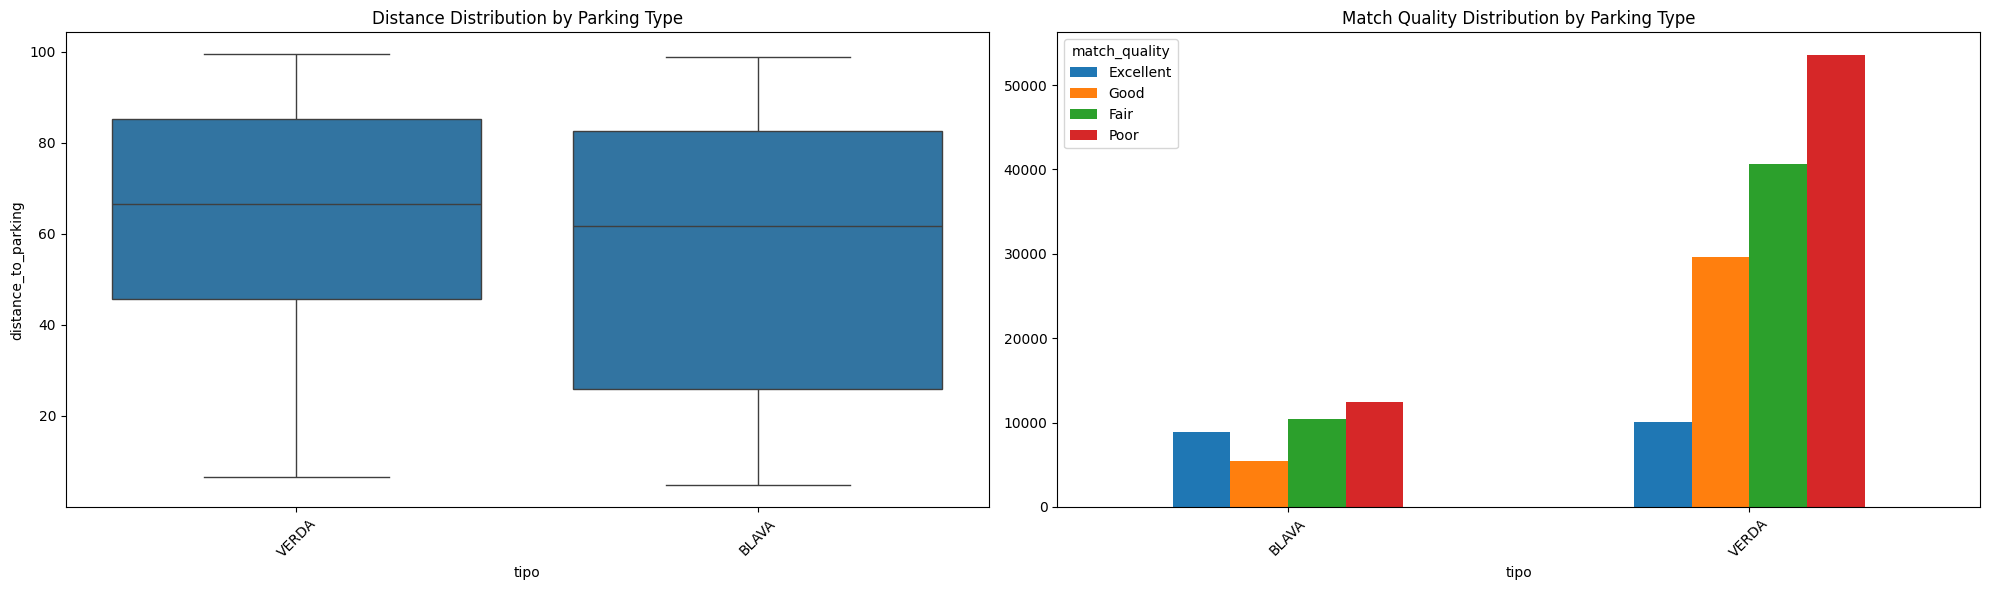

In [15]:
# Cell 5: Parking Type Analysis
def analyze_parking_types(merged_data):
    """Analyze matches by parking type (BLAVA vs VERDA)."""
    type_stats = merged_data.groupby('tipo').agg({
        'distance_to_parking': ['mean', 'count', 'min', 'max'],
        'match_quality': lambda x: x.value_counts().to_dict(),
        'tariff_numeric': 'mean'
    })
    
    # Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    
    # Distance distribution by type
    sns.boxplot(data=merged_data, x='tipo', y='distance_to_parking', ax=ax1)
    ax1.set_title('Distance Distribution by Parking Type')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
    
    # Match counts by type and quality
    merged_data.groupby(['tipo', 'match_quality']).size().unstack().plot(kind='bar', ax=ax2)
    ax2.set_title('Match Quality Distribution by Parking Type')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()
    
    return type_stats

# Run parking type analysis
type_stats = analyze_parking_types(merged_data)


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Initial Data Validation:
Total records: 171,072

Invalid occupancy values (>1): 3,840
Sample of invalid records:
     tipo  hour  occupancy_level
22  BLAVA     7                3
23  BLAVA     7                3
26  BLAVA     7                3
52  BLAVA     7                3
95  BLAVA     7                3

Occupancy by Type (Regulated Hours):
         count      mean       std  min  25%  50%  75%  max
tipo                                                       
BLAVA  18576.0  0.206072  0.404494  0.0  0.0  0.0  0.0  1.0
VERDA  66960.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0

Hourly Occupancy (Regulated Hours):
hour         8         9         10        11        12        13        14  \
tipo                                                                          
BLAVA  0.224806  0.224806  0.224806  0.224806  0.224806  0.224806  0.224806   
VERDA  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

hour         15        16        17        18   19  
tipo

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/8t/1rzjlj6n3rj3v08skl2pwjbm0000gn/T/ipykernel_23509/1317586935.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reg_data['time_block'] = pd.cut(reg_data['hour'],
/var/folders/8t/1rzjlj6n3rj3v08skl2pwjbm0000gn/T/ipykernel_23509/1317586935.py:152: UserWarning: This figure includes Axes that are not compatible


Key Relationship Analysis:

1. Tariff Analysis:

Unique tariff values:
tipo
BLAVA    [2.5, 2.25]
VERDA    [3.0, 2.75]
Name: tariff_numeric, dtype: object

Tariff statistics by type:
         count      mean       std   min   25%   50%   75%  max
tipo                                                           
BLAVA  18576.0  2.362403  0.124367  2.25  2.25  2.25  2.50  2.5
VERDA  66960.0  2.802151  0.101578  2.75  2.75  2.75  2.75  3.0

2. Temporal Dependencies:
Correlation with occupancy_lag_5: 0.197
Correlation with occupancy_lag_10: 0.197
Correlation with occupancy_lag_15: 0.197

3. Peak Occupancy Times:

BLAVA:
Peak hour: 8:00 (occupancy: 0.225)
Average occupancy: 0.206
Utilization rate: 20.6%

VERDA:
Peak hour: 8:00 (occupancy: 0.000)
Average occupancy: 0.000
Utilization rate: 0.0%


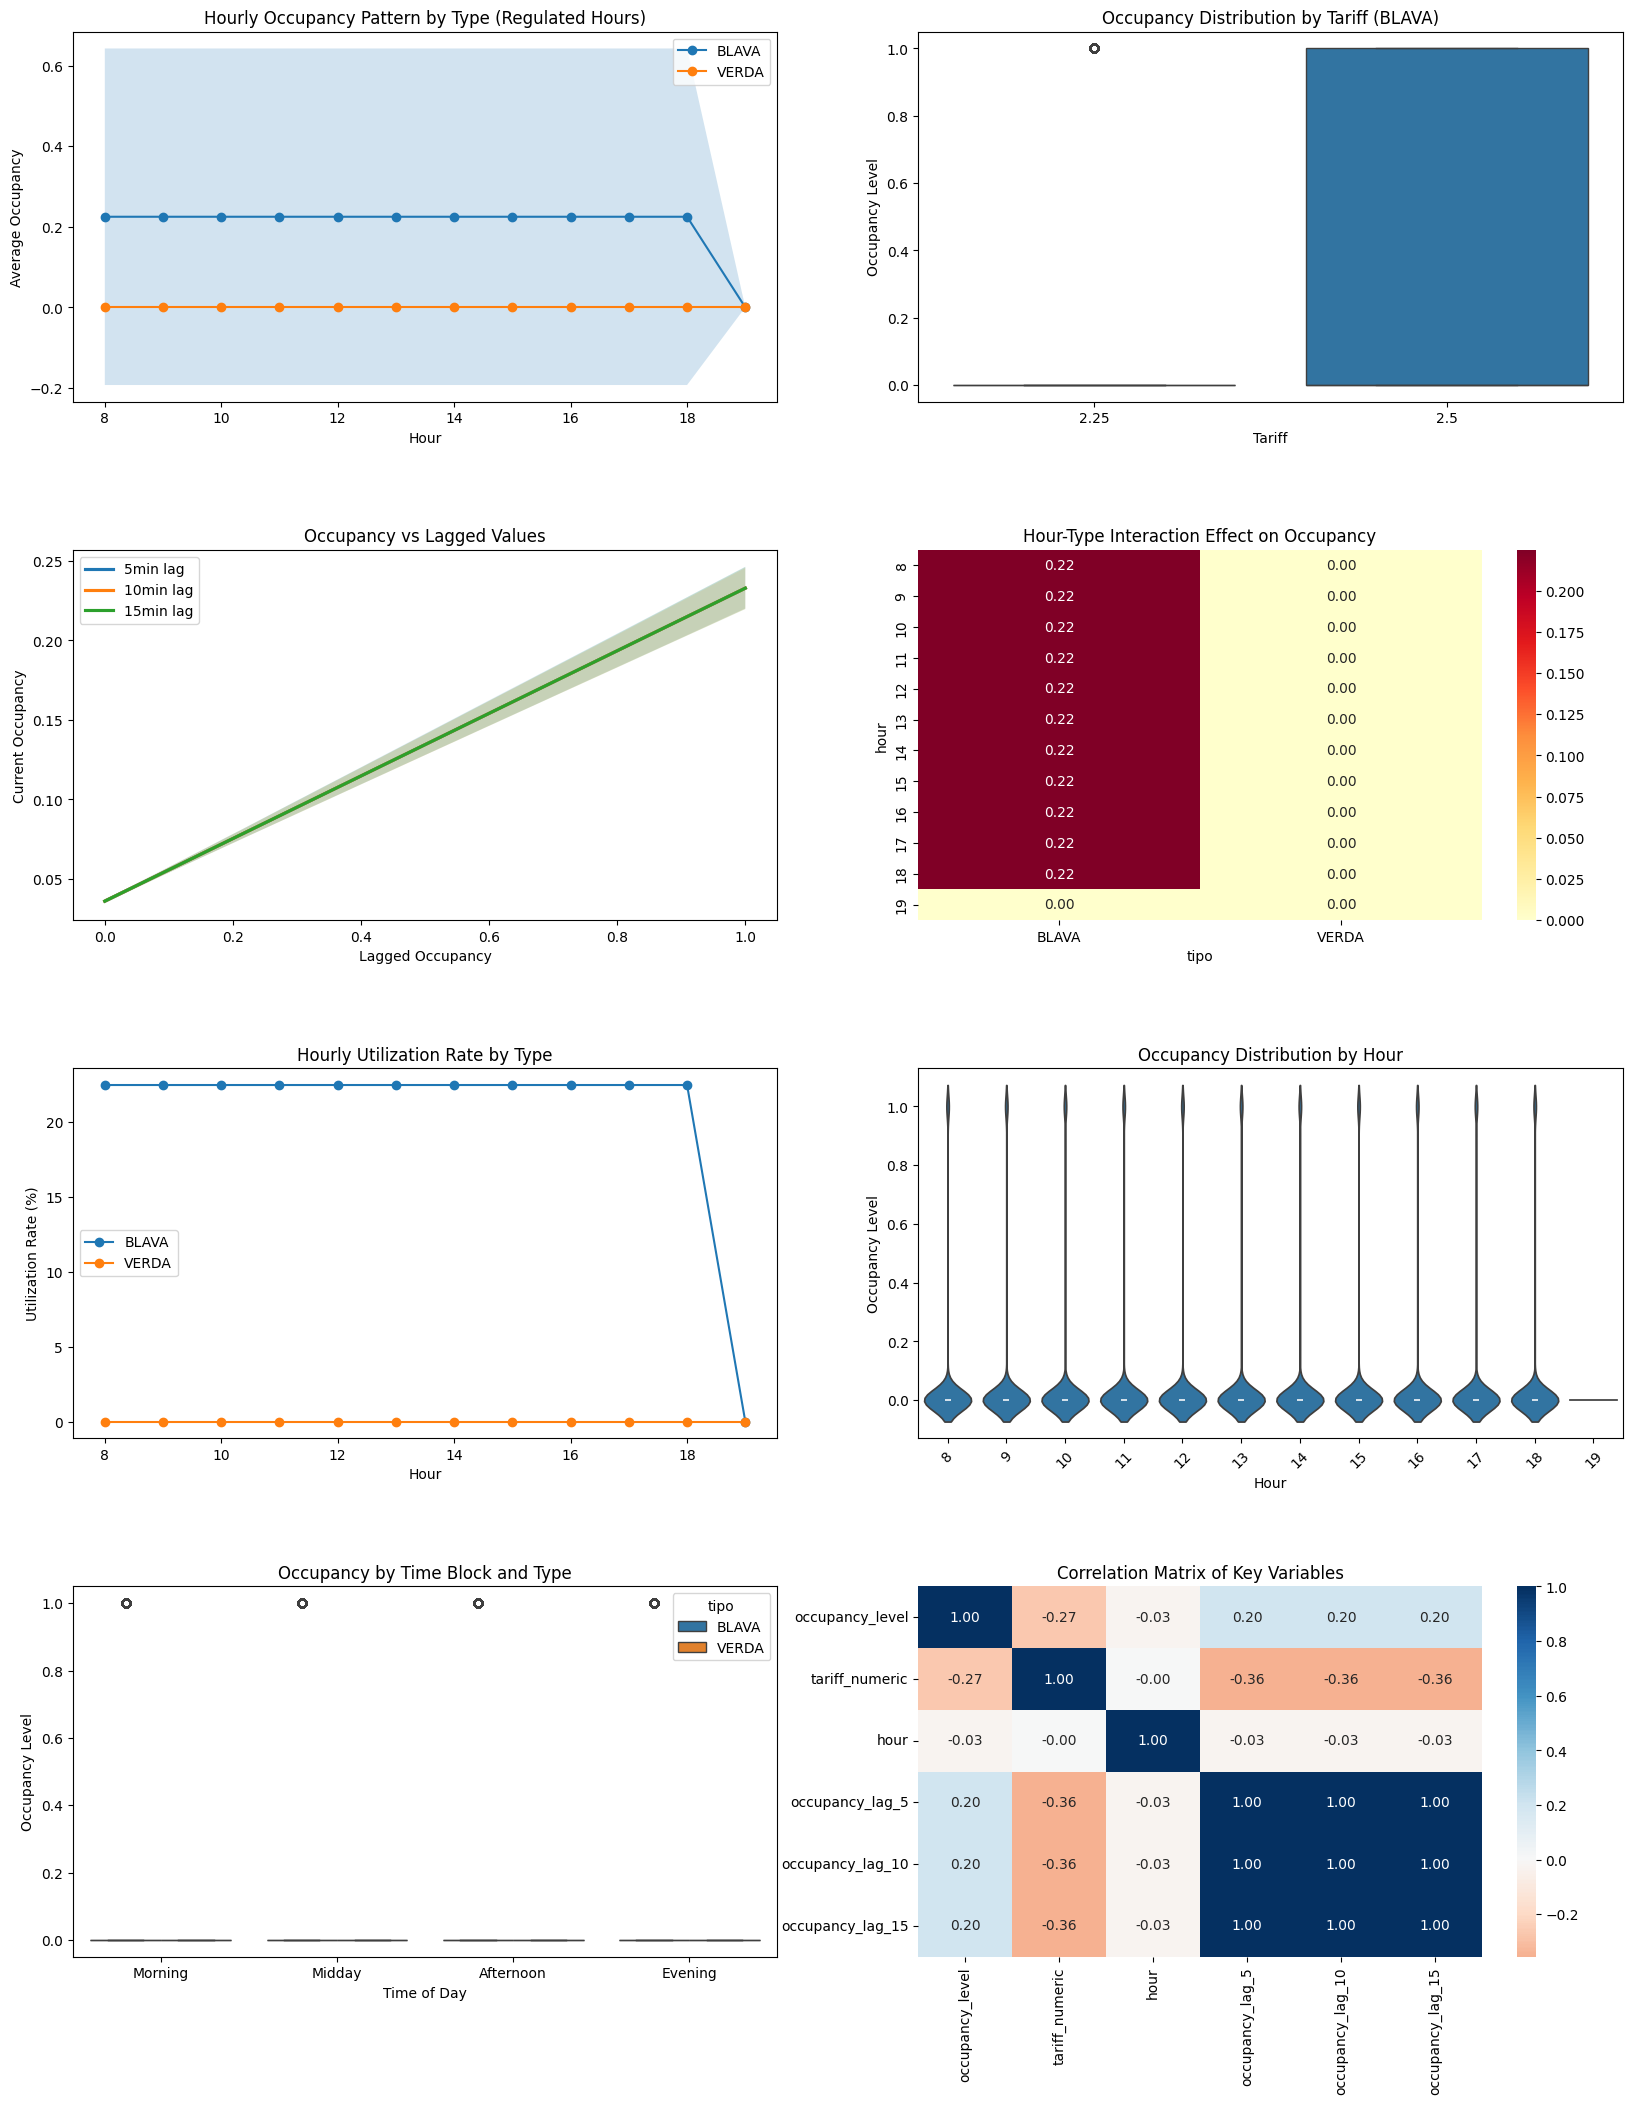

In [23]:
def validate_and_clean_data(merged_data):
    """Enhanced data validation and cleaning."""
    print("Initial Data Validation:")
    print(f"Total records: {len(merged_data):,}")
    
    # 1. Fix occupancy levels
    cleaned_data = merged_data.copy()
    
    # Log invalid occupancy values
    invalid_occ = cleaned_data[cleaned_data['occupancy_level'] > 1]
    print(f"\nInvalid occupancy values (>1): {len(invalid_occ):,}")
    print("Sample of invalid records:")
    print(invalid_occ[['tipo', 'hour', 'occupancy_level']].head())
    
    # Fix occupancy values
    cleaned_data.loc[cleaned_data['occupancy_level'] > 1, 'occupancy_level'] = 1
    cleaned_data.loc[cleaned_data['occupancy_level'] < 0, 'occupancy_level'] = 0
    
    # 2. Handle temporal aspects
    # Filter to regulated hours (assuming 8-19)
    cleaned_data['is_regulated_time'] = cleaned_data['hour'].between(8, 19)
    cleaned_data['regulated_hours'] = (cleaned_data['regulated_hours'] & 
                                     cleaned_data['is_regulated_time'])
    
    # 3. Verify type-specific patterns
    print("\nOccupancy by Type (Regulated Hours):")
    reg_data = cleaned_data[cleaned_data['regulated_hours'] == 1]
    print(reg_data.groupby('tipo')['occupancy_level'].describe())
    
    # 4. Check temporal patterns
    print("\nHourly Occupancy (Regulated Hours):")
    print(reg_data.groupby(['tipo', 'hour'])['occupancy_level'].mean().unstack())
    
    # 5. Validate lag values
    for lag in [5, 10, 15]:
        col = f'occupancy_lag_{lag}'
        # Only consider lags within same hour
        cleaned_data[col] = cleaned_data.groupby(['tipo', 'hour'])[
            'occupancy_level'].shift(1)
    
    print("\nCleaning Summary:")
    print(f"Original records: {len(merged_data):,}")
    print(f"Cleaned records: {len(cleaned_data):,}")
    print("\nValue ranges after cleaning:")
    print(cleaned_data['occupancy_level'].describe())
    
    return cleaned_data

def analyze_key_relationships(merged_data):
    """Analyze key relationships in parking data with focused visualizations."""
    
    # Create figure with focused relationships
    fig = plt.figure(figsize=(20, 25))
    gs = fig.add_gridspec(4, 2, hspace=0.4)
    
    # First validate and clean data
    cleaned_data = validate_and_clean_data(merged_data)
    
    # Filter for regulated hours
    reg_data = cleaned_data[cleaned_data['regulated_hours'] == 1]
    
    # 1. Occupancy by Hour and Type
    ax1 = fig.add_subplot(gs[0, 0])
    for tipo in reg_data['tipo'].unique():
        tipo_data = reg_data[reg_data['tipo'] == tipo]
        hourly_mean = tipo_data.groupby('hour')['occupancy_level'].mean()
        hourly_std = tipo_data.groupby('hour')['occupancy_level'].std()
        ax1.plot(hourly_mean.index, hourly_mean.values, label=tipo, marker='o')
        ax1.fill_between(hourly_mean.index, 
                        hourly_mean.values - hourly_std.values,
                        hourly_mean.values + hourly_std.values,
                        alpha=0.2)
    ax1.set_title('Hourly Occupancy Pattern by Type (Regulated Hours)')
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('Average Occupancy')
    ax1.legend()
    
    # 2. Tariff Analysis
    ax2 = fig.add_subplot(gs[0, 1])
    blava_reg = reg_data[reg_data['tipo'] == 'BLAVA']
    sns.boxplot(data=blava_reg, x='tariff_numeric', y='occupancy_level', ax=ax2)
    ax2.set_title('Occupancy Distribution by Tariff (BLAVA)')
    ax2.set_xlabel('Tariff')
    ax2.set_ylabel('Occupancy Level')
    
    # 3. Temporal Lag Analysis
    ax3 = fig.add_subplot(gs[1, 0])
    lag_cols = ['occupancy_lag_5', 'occupancy_lag_10', 'occupancy_lag_15']
    for lag_col in lag_cols:
        lag_value = int(lag_col.split('_')[-1])
        sns.regplot(data=reg_data, x=lag_col, y='occupancy_level', 
                   label=f'{lag_value}min lag',
                   scatter=False, ax=ax3)
    ax3.set_title('Occupancy vs Lagged Values')
    ax3.set_xlabel('Lagged Occupancy')
    ax3.set_ylabel('Current Occupancy')
    ax3.legend()
    
    # 4. Hour-Type Interaction Heatmap
    ax4 = fig.add_subplot(gs[1, 1])
    pivot_table = reg_data.pivot_table(
        values='occupancy_level',
        index='hour',
        columns='tipo',
        aggfunc='mean'
    )
    sns.heatmap(pivot_table, cmap='YlOrRd', annot=True, fmt='.2f', ax=ax4)
    ax4.set_title('Hour-Type Interaction Effect on Occupancy')
    
    # 5. Utilization Rate Analysis
    ax5 = fig.add_subplot(gs[2, 0])
    hourly_util = reg_data.groupby(['hour', 'tipo']).agg({
        'occupancy_level': lambda x: (x > 0).mean() * 100
    }).reset_index()
    
    for tipo in hourly_util['tipo'].unique():
        tipo_data = hourly_util[hourly_util['tipo'] == tipo]
        ax5.plot(tipo_data['hour'], tipo_data['occupancy_level'],
                label=tipo, marker='o')
    ax5.set_title('Hourly Utilization Rate by Type')
    ax5.set_xlabel('Hour')
    ax5.set_ylabel('Utilization Rate (%)')
    ax5.legend()
    
    # 6. Occupancy Distribution by Hour
    ax6 = fig.add_subplot(gs[2, 1])
    sns.violinplot(data=reg_data, x='hour', y='occupancy_level', ax=ax6)
    ax6.set_title('Occupancy Distribution by Hour')
    ax6.set_xlabel('Hour')
    ax6.set_ylabel('Occupancy Level')
    ax6.tick_params(axis='x', rotation=45)
    
    # 7. Time Block Analysis
    ax7 = fig.add_subplot(gs[3, 0])
    reg_data['time_block'] = pd.cut(reg_data['hour'], 
                                   bins=[7, 10, 13, 16, 19],
                                   labels=['Morning', 'Midday', 'Afternoon', 'Evening'])
    sns.boxplot(data=reg_data.dropna(subset=['time_block']), 
                x='time_block', y='occupancy_level', 
                hue='tipo', ax=ax7)
    ax7.set_title('Occupancy by Time Block and Type')
    ax7.set_xlabel('Time of Day')
    ax7.set_ylabel('Occupancy Level')
    
    # 8. Correlation Matrix
    ax8 = fig.add_subplot(gs[3, 1])
    corr_cols = ['occupancy_level', 'tariff_numeric', 'hour'] + lag_cols
    corr_matrix = reg_data[corr_cols].corr()
    sns.heatmap(corr_matrix, cmap='RdBu', center=0, annot=True, fmt='.2f', ax=ax8)
    ax8.set_title('Correlation Matrix of Key Variables')
    
    plt.tight_layout()
    
    # Print summary statistics
    print("\nKey Relationship Analysis:")
    
    print("\n1. Tariff Analysis:")
    print("\nUnique tariff values:")
    print(reg_data.groupby('tipo')['tariff_numeric'].unique())
    print("\nTariff statistics by type:")
    print(reg_data.groupby('tipo')['tariff_numeric'].describe())
    
    print("\n2. Temporal Dependencies:")
    for lag_col in lag_cols:
        corr = reg_data['occupancy_level'].corr(reg_data[lag_col])
        print(f"Correlation with {lag_col}: {corr:.3f}")
    
    print("\n3. Peak Occupancy Times:")
    for tipo in reg_data['tipo'].unique():
        tipo_data = reg_data[reg_data['tipo'] == tipo]
        if len(tipo_data) > 0:
            peak_hour = tipo_data.groupby('hour')['occupancy_level'].mean().idxmax()
            peak_occ = tipo_data.groupby('hour')['occupancy_level'].mean().max()
            print(f"\n{tipo}:")
            print(f"Peak hour: {peak_hour}:00 (occupancy: {peak_occ:.3f})")
            print(f"Average occupancy: {tipo_data['occupancy_level'].mean():.3f}")
            print(f"Utilization rate: {(tipo_data['occupancy_level'] > 0).mean()*100:.1f}%")
    
    return fig

# Run focused analysis
fig = analyze_key_relationships(merged_data)
plt.show()

In [ ]:
# Cell 6: Geographical Analysis
def analyze_geographical_patterns(merged_data):
    """Analyze matches by geographical clusters."""
    geo_stats = merged_data.groupby('geo_cluster').agg({
        'distance_to_parking': ['mean', 'count'],
        'match_quality': lambda x: x.value_counts().to_dict(),
        'tipo': lambda x: x.value_counts().to_dict()
    })
    
    # Create a folium map with cluster analysis
    center_lat = merged_data['lat'].mean()
    center_lon = merged_data['lon'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=13)
    
    # Add cluster markers
    for cluster in merged_data['geo_cluster'].unique():
        cluster_data = merged_data[merged_data['geo_cluster'] == cluster]
        folium.CircleMarker(
            location=[cluster_data['lat'].mean(), cluster_data['lon'].mean()],
            radius=50,
            popup=f'Cluster {cluster}<br>Matches: {len(cluster_data)}',
            color='red',
            fill=True
        ).add_to(m)
    
    return geo_stats, m

# Run geographical analysis
geo_stats, cluster_map = analyze_geographical_patterns(merged_data)
display(cluster_map)

In [29]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

def validate_and_clean_data(merged_data):
    """Enhanced data validation and cleaning."""
    print("Initial Data Validation:")
    print(f"Total records: {len(merged_data):,}")
    
    # 1. Fix occupancy levels
    cleaned_data = merged_data.copy()
    
    # Log invalid occupancy values
    invalid_occ = cleaned_data[cleaned_data['occupancy_level'] > 1]
    print(f"\nInvalid occupancy values (>1): {len(invalid_occ):,}")
    print("Sample of invalid records:")
    print(invalid_occ[['tipo', 'hour', 'occupancy_level']].head())
    
    # Fix occupancy values
    cleaned_data.loc[cleaned_data['occupancy_level'] > 1, 'occupancy_level'] = 1
    cleaned_data.loc[cleaned_data['occupancy_level'] < 0, 'occupancy_level'] = 0
    
    # 2. Handle temporal aspects
    # Filter to regulated hours (assuming 8-19)
    cleaned_data['is_regulated_time'] = cleaned_data['hour'].between(8, 19)
    cleaned_data['regulated_hours'] = (cleaned_data['regulated_hours'] & 
                                     cleaned_data['is_regulated_time'])
    
    # 3. Verify type-specific patterns
    print("\nOccupancy by Type (Regulated Hours):")
    reg_data = cleaned_data[cleaned_data['regulated_hours'] == 1]
    print(reg_data.groupby('tipo')['occupancy_level'].describe())
    
    # 4. Check temporal patterns
    print("\nHourly Occupancy (Regulated Hours):")
    print(reg_data.groupby(['tipo', 'hour'])['occupancy_level'].mean().unstack())
    
    # 5. Validate lag values
    for lag in [5, 10, 15]:
        col = f'occupancy_lag_{lag}'
        # Only consider lags within same hour
        cleaned_data[col] = cleaned_data.groupby(['tipo', 'hour'])[
            'occupancy_level'].shift(1)
    
    print("\nCleaning Summary:")
    print(f"Original records: {len(merged_data):,}")
    print(f"Cleaned records: {len(cleaned_data):,}")
    print("\nValue ranges after cleaning:")
    print(cleaned_data['occupancy_level'].describe())
    
    return cleaned_data

def perform_statistical_tests(cleaned_data):
    """Perform comprehensive statistical tests on the parking data."""
    
    # Filter for regulated hours
    reg_data = cleaned_data[cleaned_data['regulated_hours'] == 1]
    
    print("Statistical Analysis Report")
    print("=" * 50)
    
    # 1. Basic Statistics
    print("\n1. Basic Statistics by Type")
    print("-" * 30)
    
    for tipo in reg_data['tipo'].unique():
        tipo_data = reg_data[reg_data['tipo'] == tipo]
        print(f"\n{tipo}:")
        print("Occupancy Statistics:")
        print(tipo_data['occupancy_level'].describe())
        print(f"Non-zero occupancy: {(tipo_data['occupancy_level'] > 0).mean()*100:.1f}%")
    
    # 2. Type Comparison (if variation exists)
    print("\n2. Type Comparison")
    print("-" * 30)
    
    blava_occ = reg_data[reg_data['tipo'] == 'BLAVA']['occupancy_level']
    verda_occ = reg_data[reg_data['tipo'] == 'VERDA']['occupancy_level']
    
    if blava_occ.std() > 0 or verda_occ.std() > 0:
        try:
            stat, pval = stats.mannwhitneyu(blava_occ, verda_occ, alternative='two-sided')
            print("\nMann-Whitney U test results:")
            print(f"Statistic: {stat:.2f}")
            print(f"p-value: {pval:.4f}")
        except ValueError as e:
            print(f"Could not perform Mann-Whitney U test: {e}")
    else:
        print("No variation between types for statistical comparison")
    
    # 3. Temporal Patterns
    print("\n3. Temporal Patterns")
    print("-" * 30)
    
    for tipo in reg_data['tipo'].unique():
        print(f"\n{tipo} Temporal Analysis:")
        tipo_data = reg_data[reg_data['tipo'] == tipo]
        
        # Hourly patterns
        hourly_stats = tipo_data.groupby('hour')['occupancy_level'].agg(['mean', 'std', 'count'])
        print("\nHourly Statistics:")
        print(hourly_stats)
        
        # Check for any variation
        if hourly_stats['std'].max() > 0:
            print("\nHour-to-hour variation detected")
            try:
                # Only include groups with variation
                valid_groups = [group['occupancy_level'].values 
                              for _, group in tipo_data.groupby('hour')
                              if group['occupancy_level'].std() > 0]
                
                if len(valid_groups) > 1:
                    h_stat, h_pval = stats.kruskal(*valid_groups)
                    print(f"Kruskal-Wallis test results:")
                    print(f"H-statistic: {h_stat:.2f}")
                    print(f"p-value: {h_pval:.4f}")
                else:
                    print("Insufficient groups with variation for Kruskal-Wallis test")
            except ValueError as e:
                print(f"Could not perform Kruskal-Wallis test: {e}")
        else:
            print("No hour-to-hour variation detected")
    
    # 4. Tariff Analysis
    print("\n4. Tariff Analysis")
    print("-" * 30)
    
    for tipo in reg_data['tipo'].unique():
        print(f"\n{tipo} Tariff Analysis:")
        tipo_data = reg_data[reg_data['tipo'] == tipo]
        
        print("\nTariff Distribution:")
        print(tipo_data['tariff_numeric'].describe())
        
        if (tipo_data['occupancy_level'].std() > 0 and 
            tipo_data['tariff_numeric'].std() > 0):
            try:
                corr, pval = stats.spearmanr(tipo_data['tariff_numeric'],
                                           tipo_data['occupancy_level'])
                print("\nSpearman Correlation:")
                print(f"Correlation: {corr:.3f}")
                print(f"p-value: {pval:.4f}")
            except ValueError as e:
                print(f"Could not compute correlation: {e}")
        else:
            print("Insufficient variation for correlation analysis")
    
    # 5. Utilization Analysis
    print("\n5. Utilization Analysis")
    print("-" * 30)
    
    for tipo in reg_data['tipo'].unique():
        print(f"\n{tipo} Utilization:")
        tipo_data = reg_data[reg_data['tipo'] == tipo]
        
        util_rate = (tipo_data['occupancy_level'] > 0).mean()
        print(f"Overall utilization rate: {util_rate:.3f}")
        
        if util_rate > 0 and util_rate < 1:
            # Use binomtest instead of proportion_confint
            n_success = (tipo_data['occupancy_level'] > 0).sum()
            n_total = len(tipo_data)
            binom_test = stats.binomtest(n_success, n_total)
            ci = binom_test.proportion_ci()
            print(f"95% CI: ({ci.low:.3f}, {ci.high:.3f})")
        else:
            print("Constant utilization - no confidence interval computed")
    
    return reg_data

# First clean the data
cleaned_data = validate_and_clean_data(merged_data)

# Then run statistical tests
reg_data = perform_statistical_tests(cleaned_data)

Initial Data Validation:
Total records: 171,072

Invalid occupancy values (>1): 3,840
Sample of invalid records:
     tipo  hour  occupancy_level
22  BLAVA     7                3
23  BLAVA     7                3
26  BLAVA     7                3
52  BLAVA     7                3
95  BLAVA     7                3

Occupancy by Type (Regulated Hours):
         count      mean       std  min  25%  50%  75%  max
tipo                                                       
BLAVA  18576.0  0.206072  0.404494  0.0  0.0  0.0  0.0  1.0
VERDA  66960.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0

Hourly Occupancy (Regulated Hours):
hour         8         9         10        11        12        13        14  \
tipo                                                                          
BLAVA  0.224806  0.224806  0.224806  0.224806  0.224806  0.224806  0.224806   
VERDA  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

hour         15        16        17        18   19  
tipo

In [30]:
def investigate_verda_occupancy(merged_data):
    """Investigate why VERDA parking shows no occupancy."""
    print("VERDA Occupancy Investigation")
    print("=" * 50)
    
    # 1. Check raw data before cleaning
    print("\n1. Raw Data Check:")
    verda_raw = merged_data[merged_data['tipo'] == 'VERDA']
    print("\nVERDA raw occupancy statistics:")
    print(verda_raw['occupancy_level'].describe())
    print(f"\nUnique occupancy values: {sorted(verda_raw['occupancy_level'].unique())}")
    
    # 2. Check data distribution
    print("\n2. Data Distribution:")
    print("\nVERDA records by hour:")
    print(verda_raw.groupby('hour')['occupancy_level'].agg(['count', 'mean', 'min', 'max']))
    
    # 3. Check for potential data issues
    print("\n3. Data Quality Check:")
    print(f"Missing values: {verda_raw['occupancy_level'].isna().sum()}")
    print(f"Negative values: {(verda_raw['occupancy_level'] < 0).sum()}")
    print(f"Values > 1: {(verda_raw['occupancy_level'] > 1).sum()}")
    
    # 4. Compare with BLAVA
    print("\n4. Comparison with BLAVA:")
    blava_raw = merged_data[merged_data['tipo'] == 'BLAVA']
    print("\nBLAVA vs VERDA summary:")
    comparison_df = pd.DataFrame({
        'BLAVA': blava_raw['occupancy_level'].describe(),
        'VERDA': verda_raw['occupancy_level'].describe()
    })
    print(comparison_df)
    
    # 5. Check temporal patterns
    print("\n5. Temporal Pattern Check:")
    print("\nVERDA occupancy by day and hour:")
    pivot = pd.pivot_table(
        verda_raw,
        values='occupancy_level',
        index='hour',
        columns='day_of_week',
        aggfunc='mean'
    )
    print(pivot)
    
    # 6. Check related variables
    print("\n6. Related Variables Check:")
    print("\nVERDA tariff distribution:")
    print(verda_raw['tariff_numeric'].describe())
    print("\nVERDA match quality distribution:")
    print(verda_raw['match_quality'].value_counts(normalize=True))
    
    # 7. Check for any non-zero values
    non_zero = verda_raw[verda_raw['occupancy_level'] > 0]
    if len(non_zero) > 0:
        print("\n7. Non-zero VERDA records:")
        print(non_zero[['hour', 'day_of_week', 'occupancy_level', 'tariff_numeric', 'match_quality']].head())
    else:
        print("\n7. No non-zero VERDA records found")
    
    return verda_raw

# Run investigation
verda_data = investigate_verda_occupancy(merged_data)

VERDA Occupancy Investigation

1. Raw Data Check:

VERDA raw occupancy statistics:
count    133920.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: occupancy_level, dtype: float64

Unique occupancy values: [np.int64(0)]

2. Data Distribution:

VERDA records by hour:
      count  mean  min  max
hour                       
0      5580   0.0    0    0
1      5580   0.0    0    0
2      5580   0.0    0    0
3      5580   0.0    0    0
4      5580   0.0    0    0
5      5580   0.0    0    0
6      5580   0.0    0    0
7      5580   0.0    0    0
8      5580   0.0    0    0
9      5580   0.0    0    0
10     5580   0.0    0    0
11     5580   0.0    0    0
12     5580   0.0    0    0
13     5580   0.0    0    0
14     5580   0.0    0    0
15     5580   0.0    0    0
16     5580   0.0    0    0
17     5580   0.0    0    0
18     5580   0.0    0    0
19     5580   0.0    0    0
20     5580   0.0    0    0
21  

Data Distribution:

Unique days: [np.int32(4), np.int32(5)]
Unique hours: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]

Value counts for day_of_week:
day_of_week
4    121176
5     49896
Name: count, dtype: int64


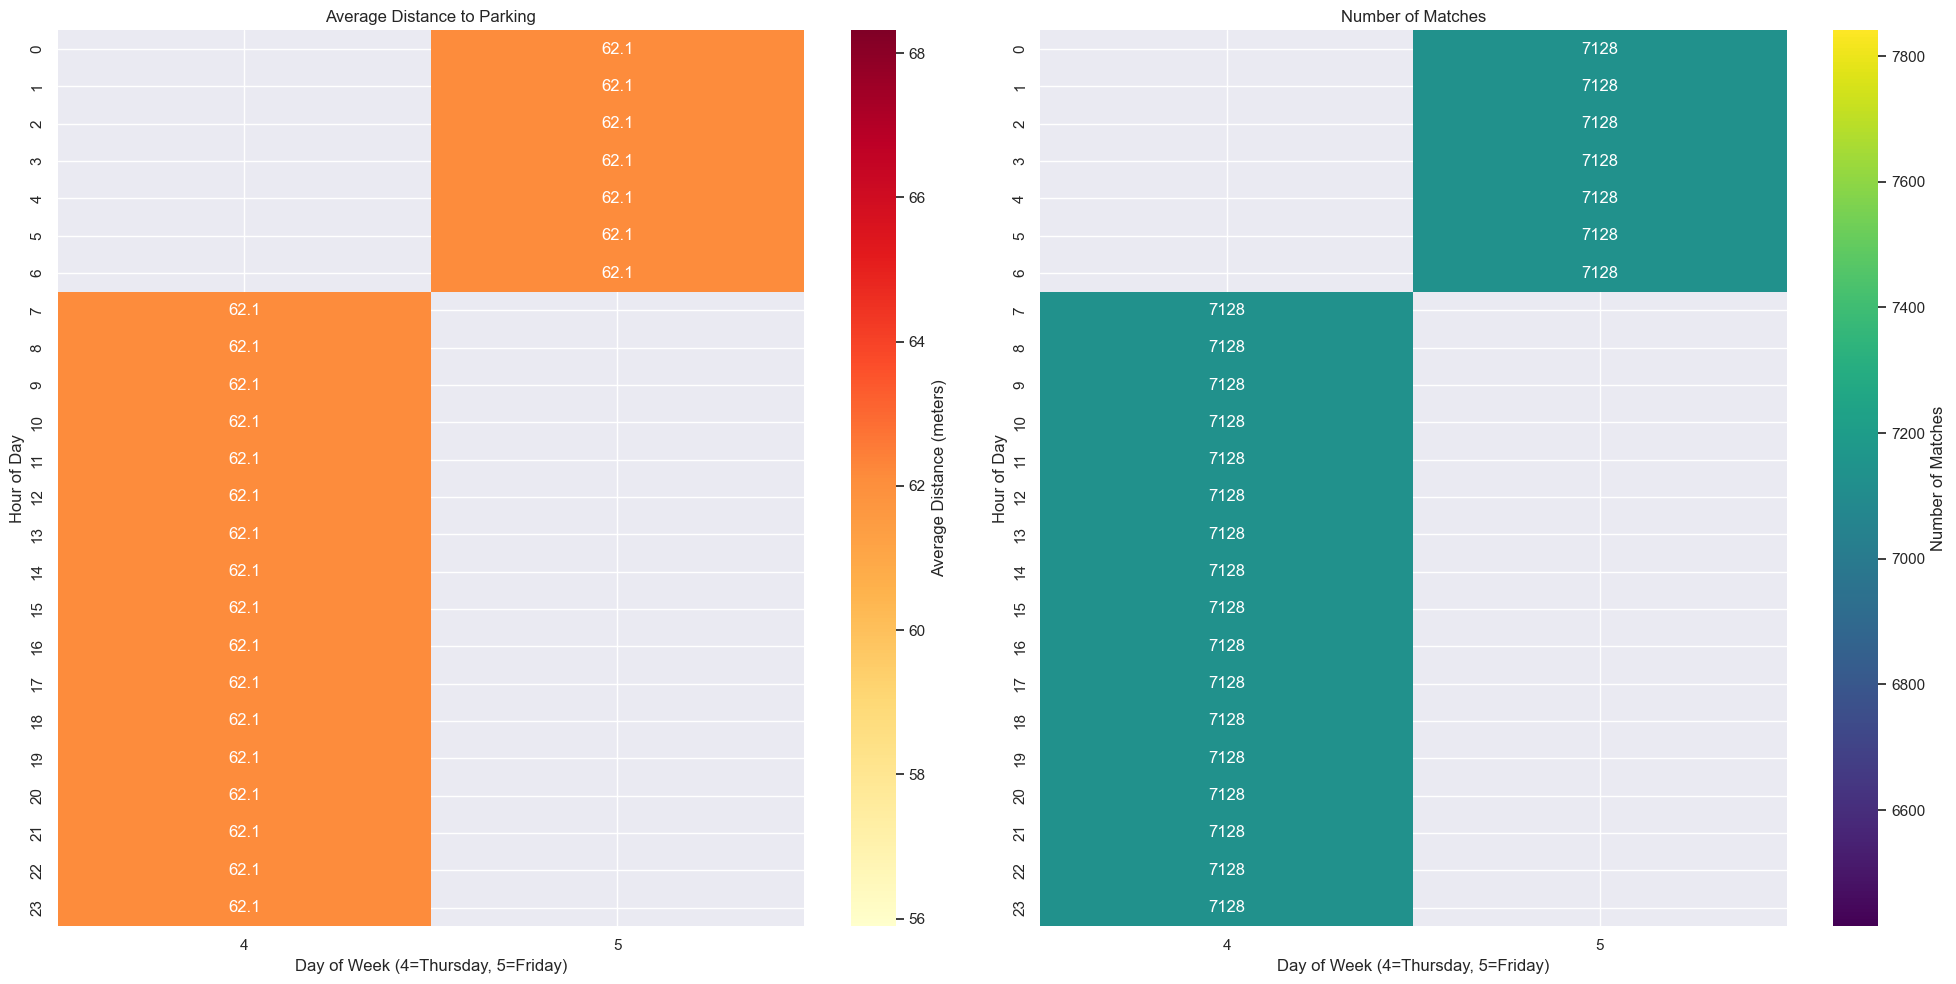


Detailed distance statistics:
day_of_week      4      5
hour                     
0              NaN  62.11
1              NaN  62.11
2              NaN  62.11
3              NaN  62.11
4              NaN  62.11
5              NaN  62.11
6              NaN  62.11
7            62.11    NaN
8            62.11    NaN
9            62.11    NaN
10           62.11    NaN
11           62.11    NaN
12           62.11    NaN
13           62.11    NaN
14           62.11    NaN
15           62.11    NaN
16           62.11    NaN
17           62.11    NaN
18           62.11    NaN
19           62.11    NaN
20           62.11    NaN
21           62.11    NaN
22           62.11    NaN
23           62.11    NaN

Detailed count statistics:
day_of_week       4       5
hour                       
0               NaN  7128.0
1               NaN  7128.0
2               NaN  7128.0
3               NaN  7128.0
4               NaN  7128.0
5               NaN  7128.0
6               NaN  7128.0
7            

In [16]:
def create_time_heatmap(merged_data):
    """Create a detailed heatmap analysis of matches across time dimensions."""
    # No need to convert datetime since we already have day_of_week and hour
    
    # Print data distribution information
    print("Data Distribution:")
    print("\nUnique days:", sorted(merged_data['day_of_week'].unique()))
    print("Unique hours:", sorted(merged_data['hour'].unique()))
    print("\nValue counts for day_of_week:")
    print(merged_data['day_of_week'].value_counts().sort_index())
    
    # Create pivot tables for both metrics
    distance_pivot = pd.pivot_table(
        merged_data,
        values='distance_to_parking',
        index='hour',
        columns='day_of_week',
        aggfunc='mean'
    )
    
    count_pivot = pd.pivot_table(
        merged_data,
        values='distance_to_parking',
        index='hour',
        columns='day_of_week',
        aggfunc='count'
    )
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # 1. Average Distance Heatmap
    sns.heatmap(
        distance_pivot,
        cmap='YlOrRd',
        annot=True,
        fmt='.1f',
        cbar_kws={'label': 'Average Distance (meters)'},
        ax=ax1,
        mask=distance_pivot.isna()  # Only show cells with data
    )
    ax1.set_title('Average Distance to Parking')
    ax1.set_xlabel('Day of Week (4=Thursday, 5=Friday)')
    ax1.set_ylabel('Hour of Day')
    
    # 2. Count Heatmap
    sns.heatmap(
        count_pivot,
        cmap='viridis',
        annot=True,
        fmt='.0f',
        cbar_kws={'label': 'Number of Matches'},
        ax=ax2,
        mask=count_pivot.isna()  # Only show cells with data
    )
    ax2.set_title('Number of Matches')
    ax2.set_xlabel('Day of Week (4=Thursday, 5=Friday)')
    ax2.set_ylabel('Hour of Day')
    
    plt.tight_layout()
    plt.show()
    
    # Return both pivot tables for detailed analysis
    return {'distance': distance_pivot, 'count': count_pivot}

# Run enhanced time heatmap analysis
time_stats = create_time_heatmap(merged_data)

# Print detailed statistics
print("\nDetailed distance statistics:")
print(time_stats['distance'].round(2))
print("\nDetailed count statistics:")
print(time_stats['count'].round(0))


In [18]:
# Cell 8: Save Results
def prepare_stats_for_json(stats_dict):
    """Convert pandas objects and complex types to JSON-serializable format."""
    processed_dict = {}
    
    for key, value in stats_dict.items():
        if isinstance(value, dict):
            processed_dict[key] = prepare_stats_for_json(value)
        elif isinstance(value, pd.DataFrame):
            # Convert MultiIndex columns to string
            if isinstance(value.columns, pd.MultiIndex):
                value.columns = [f"{col[0]}_{col[1]}" for col in value.columns]
            processed_dict[key] = value.to_dict(orient='index')
        elif isinstance(value, pd.Series):
            processed_dict[key] = value.to_dict()
        else:
            processed_dict[key] = value
    
    return processed_dict

# Create output directory
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Prepare results dictionary
results = {
    'basic_stats': stats,
    'hourly_stats': hourly_stats,
    'dow_stats': dow_stats,
    'type_stats': type_stats,
    'geo_stats': geo_stats
}

# Process results for JSON serialization
processed_results = prepare_stats_for_json(results)

# Save with timestamp
from datetime import datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_file = output_dir / f'parking_analysis_{timestamp}.json'

with open(output_file, 'w') as f:
    json.dump(processed_results, f, indent=2)

logger.info(f"Analysis results saved to: {output_file}")

# Also save the merged data
merged_data_file = output_dir / f'merged_parking_data_{timestamp}.csv'
merged_data.to_csv(merged_data_file, index=False)
logger.info(f"Merged data saved to: {merged_data_file}")

INFO:__main__:Analysis results saved to: output/parking_analysis_20250222_163751.json
INFO:__main__:Merged data saved to: output/merged_parking_data_20250222_163751.csv


In [20]:
# Cell: Extreme Value Analysis
def analyze_extreme_values(data):
    """Analyze extreme values in numerical features."""
    # Define numerical columns to analyze
    numerical_cols = ['occupancy_level', 'tariff_numeric', 'distance_to_parking']
    if 'occupancy_lag_5' in data.columns:
        numerical_cols.extend(['occupancy_lag_5', 'occupancy_lag_10', 'occupancy_lag_15'])
    
    print("Extreme Value Analysis:")
    print("-" * 50)
    
    for col in numerical_cols:
        # Calculate statistics
        stats = data[col].describe()
        iqr = stats['75%'] - stats['25%']
        lower_bound = stats['25%'] - (1.5 * iqr)
        upper_bound = stats['75%'] + (1.5 * iqr)
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        
        print(f"\n{col}:")
        print(f"Statistics:\n{stats}")
        print(f"Number of outliers: {len(outliers)}")
        print(f"Outlier percentage: {(len(outliers) / len(data)) * 100:.2f}%")
        
        # Visualize distribution with outliers
        plt.figure(figsize=(12, 4))
        
        # Box plot
        plt.subplot(1, 2, 1)
        sns.boxplot(x=data[col])
        plt.title(f'{col} Distribution')
        
        # Histogram with KDE
        plt.subplot(1, 2, 2)
        sns.histplot(data=data, x=col, kde=True)
        plt.axvline(lower_bound, color='r', linestyle='--', alpha=0.5)
        plt.axvline(upper_bound, color='r', linestyle='--', alpha=0.5)
        plt.title(f'{col} Histogram with Outlier Bounds')
        
        plt.tight_layout()
        plt.show()
        
        # Show example outliers
        if len(outliers) > 0:
            print("\nExample outliers:")
            print(outliers[[col, 'datetime', 'tipo', 'tramo']].head())


In [21]:
# Cell: Temporal Anomaly Analysis
def analyze_temporal_anomalies(data):
    """Analyze temporal patterns and identify anomalies."""
    print("Temporal Anomaly Analysis:")
    print("-" * 50)
    
    # Group by time components
    hourly_stats = data.groupby('hour')['occupancy_level'].agg(['mean', 'std', 'count'])
    
    # Calculate z-scores for each hour
    hourly_anomalies = data.copy()
    hourly_anomalies['hour_mean'] = hourly_anomalies['hour'].map(hourly_stats['mean'])
    hourly_anomalies['hour_std'] = hourly_anomalies['hour'].map(hourly_stats['std'])
    hourly_anomalies['z_score'] = (hourly_anomalies['occupancy_level'] - hourly_anomalies['hour_mean']) / hourly_anomalies['hour_std']
    
    # Identify anomalies (z-score > 3 or < -3)
    anomalies = hourly_anomalies[abs(hourly_anomalies['z_score']) > 3]
    
    # Visualizations
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))
    
    # 1. Average occupancy by hour
    sns.lineplot(data=hourly_stats, y='mean', x=hourly_stats.index, ax=ax1)
    ax1.set_title('Average Occupancy by Hour')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Average Occupancy')
    
    # 2. Occupancy standard deviation by hour
    sns.lineplot(data=hourly_stats, y='std', x=hourly_stats.index, ax=ax2)
    ax2.set_title('Occupancy Variability by Hour')
    ax2.set_xlabel('Hour of Day')
    ax2.set_ylabel('Standard Deviation')
    
    # 3. Z-score distribution
    sns.histplot(data=hourly_anomalies, x='z_score', ax=ax3)
    ax3.axvline(-3, color='r', linestyle='--')
    ax3.axvline(3, color='r', linestyle='--')
    ax3.set_title('Z-score Distribution')
    
    # 4. Anomalies over time
    sns.scatterplot(data=data, x='hour', y='occupancy_level', alpha=0.1, ax=ax4)
    sns.scatterplot(data=anomalies, x='hour', y='occupancy_level', 
                    color='red', ax=ax4)
    ax4.set_title('Occupancy Anomalies by Hour')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nAnomaly Summary:")
    print(f"Total anomalies found: {len(anomalies)}")
    print(f"Percentage of anomalies: {(len(anomalies) / len(data)) * 100:.2f}%")
    
    if len(anomalies) > 0:
        print("\nExample anomalies:")
        print(anomalies[['datetime', 'hour', 'occupancy_level', 'z_score', 'tipo', 'tramo']].head())
        
        print("\nAnomaly distribution by hour:")
        print(anomalies['hour'].value_counts().sort_index())
        
        print("\nAnomaly distribution by parking type:")
        print(anomalies['tipo'].value_counts())

Extreme Value Analysis:
--------------------------------------------------

occupancy_level:
Statistics:
count    171072.000000
mean          0.068042
std           0.439366
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: occupancy_level, dtype: float64
Number of outliers: 4176
Outlier percentage: 2.44%


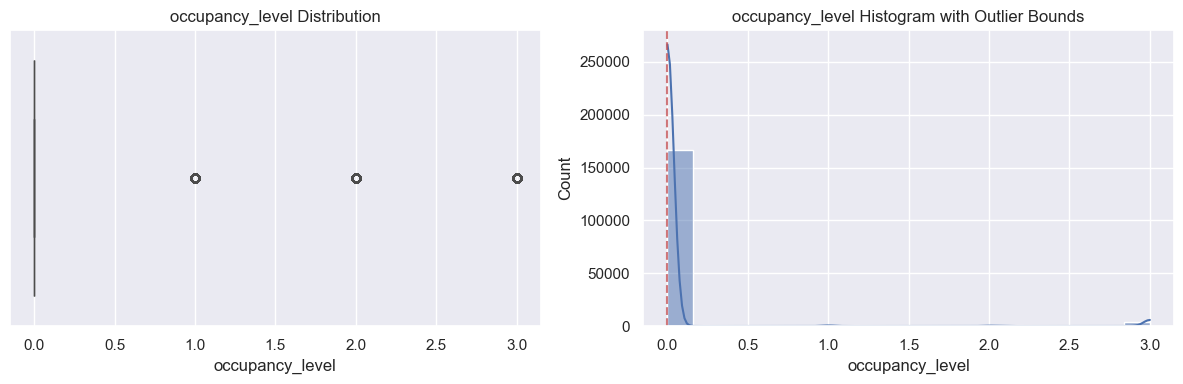


Example outliers:
    occupancy_level                  datetime   tipo  \
22                3 2025-01-31 07:00:00+00:00  BLAVA   
23                3 2025-01-31 07:00:00+00:00  BLAVA   
26                3 2025-01-31 07:00:00+00:00  BLAVA   
52                3 2025-01-31 07:00:00+00:00  BLAVA   
79                1 2025-01-31 07:00:00+00:00  BLAVA   

                           tramo  
22  PAS  SOTA MURALLA, FRENTE 11  
23      CARRER  MUNTANER, FTE, 3  
26   PAS  SOTA MURALLA, frente 9  
52          CARRER  CORSEGA, 441  
79         AVINGUDA  ICARIA, 137  

tariff_numeric:
Statistics:
count    171072.000000
mean          2.706650
std           0.210504
min           2.250000
25%           2.750000
50%           2.750000
75%           2.750000
max           3.000000
Name: tariff_numeric, dtype: float64
Number of outliers: 65088
Outlier percentage: 38.05%


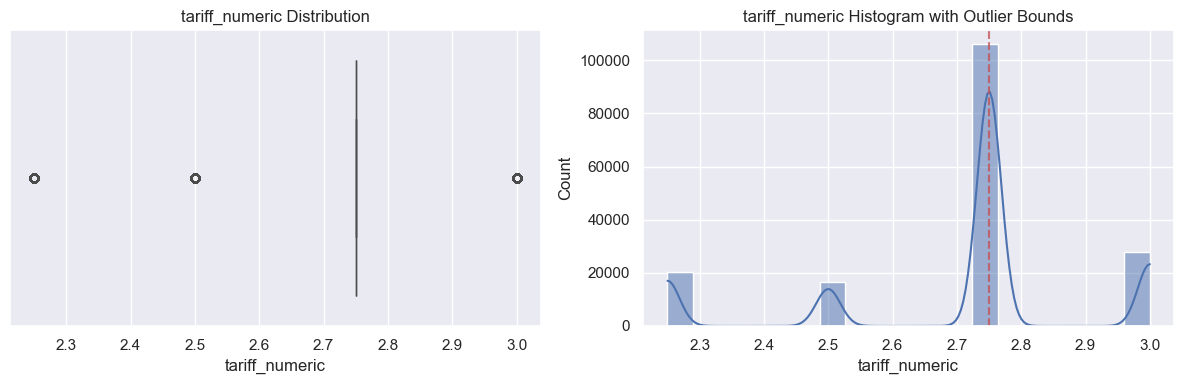


Example outliers:
    tariff_numeric                  datetime   tipo                  tramo
12            2.25 2025-01-31 07:00:00+00:00  BLAVA  CARRER  ESCORIAL, 165
14            2.25 2025-01-31 07:00:00+00:00  BLAVA   CARRER  PADILLA, 326
16            3.00 2025-01-31 07:00:00+00:00  VERDA  CARRER  ROSSELLO, 312
17            3.00 2025-01-31 07:00:00+00:00  VERDA  CARRER  ROSSELLO, 484
18            3.00 2025-01-31 07:00:00+00:00  VERDA   CARRER  PADILLA, 317

distance_to_parking:
Statistics:
count    171072.000000
mean         62.105298
std          25.208414
min           4.744646
25%          43.388243
50%          65.750072
75%          84.618731
max          99.493425
Name: distance_to_parking, dtype: float64
Number of outliers: 0
Outlier percentage: 0.00%


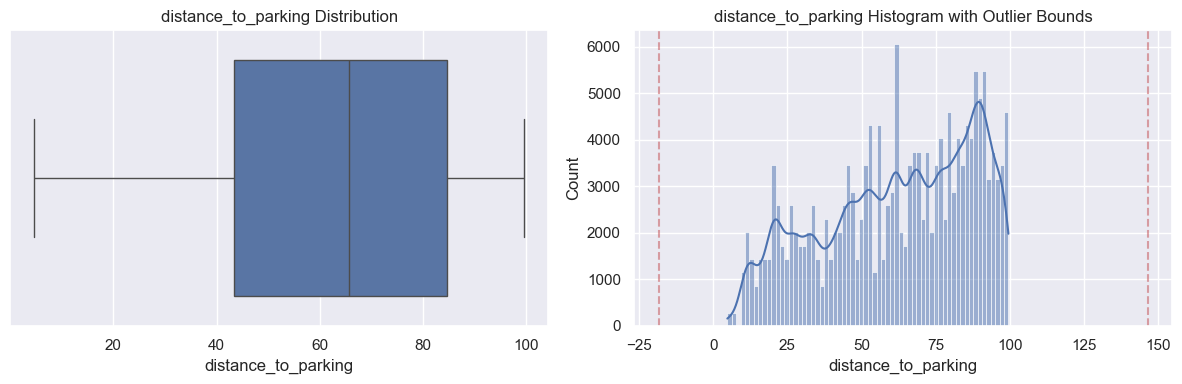


occupancy_lag_5:
Statistics:
count    170478.000000
mean          0.068279
std           0.440113
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: occupancy_lag_5, dtype: float64
Number of outliers: 4176
Outlier percentage: 2.44%


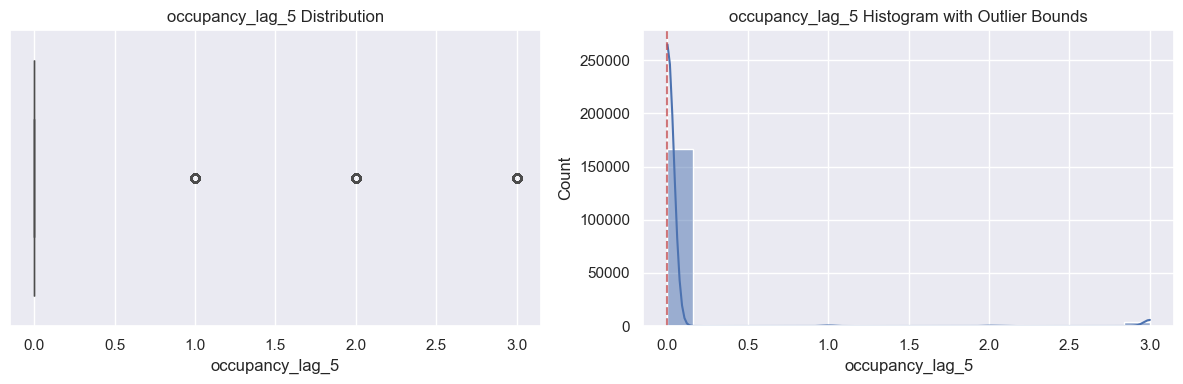


Example outliers:
     occupancy_lag_5                  datetime   tipo  \
599              3.0 2025-01-31 07:05:00+00:00  BLAVA   
630              3.0 2025-01-31 07:05:00+00:00  BLAVA   
631              3.0 2025-01-31 07:05:00+00:00  BLAVA   
643              3.0 2025-01-31 07:05:00+00:00  BLAVA   
652              3.0 2025-01-31 07:05:00+00:00  BLAVA   

                        tramo  
599  CARRER  BUENOS AIRES, 47  
630      CARRER  BAILEN, 88 b  
631       CARRER  BAILEN, 85   
643        CARRER  ARAGO, 225  
652        CARRER  ARAGO, 360  

occupancy_lag_10:
Statistics:
count    169884.000000
mean          0.068517
std           0.440863
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: occupancy_lag_10, dtype: float64
Number of outliers: 4176
Outlier percentage: 2.44%


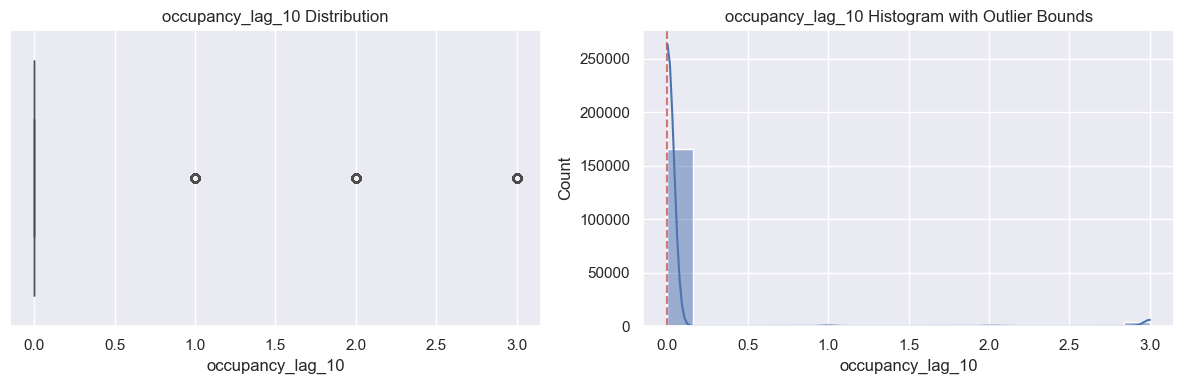


Example outliers:
      occupancy_lag_10                  datetime   tipo  \
1309               3.0 2025-01-31 07:10:00+00:00  BLAVA   
1356               3.0 2025-01-31 07:10:00+00:00  BLAVA   
1368               3.0 2025-01-31 07:10:00+00:00  BLAVA   
1370               3.0 2025-01-31 07:10:00+00:00  BLAVA   
1374               3.0 2025-01-31 07:10:00+00:00  BLAVA   

                           tramo  
1309  CARRER  COMTE D'URGELL, 50  
1356         CARRER  LONDRES, 94  
1368        CARRER  BAILEN, 88 b  
1370          CARRER  ARAGO, 360  
1374         CARRER  BAILEN, 85   

occupancy_lag_15:
Statistics:
count    169290.000000
mean          0.068758
std           0.441617
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: occupancy_lag_15, dtype: float64
Number of outliers: 4176
Outlier percentage: 2.44%


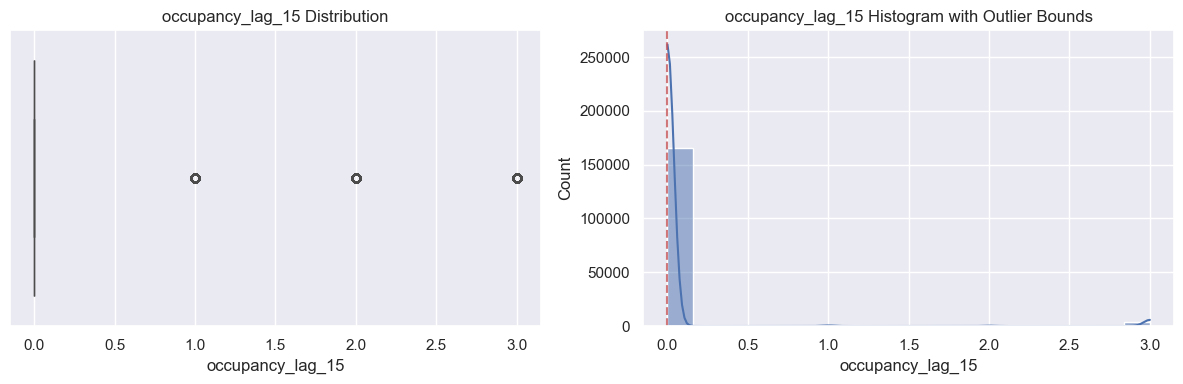


Example outliers:
      occupancy_lag_15                  datetime   tipo  \
1792               3.0 2025-01-31 07:15:00+00:00  BLAVA   
1810               3.0 2025-01-31 07:15:00+00:00  BLAVA   
1818               1.0 2025-01-31 07:15:00+00:00  BLAVA   
1854               3.0 2025-01-31 07:15:00+00:00  BLAVA   
1860               3.0 2025-01-31 07:15:00+00:00  BLAVA   

                             tramo  
1792  PAS  SOTA MURALLA, FRENTE 11  
1810   PAS  SOTA MURALLA, frente 9  
1818         AVINGUDA  ICARIA, 137  
1854      CARRER  MUNTANER, FTE, 3  
1860          CARRER  CORSEGA, 441  
Temporal Anomaly Analysis:
--------------------------------------------------


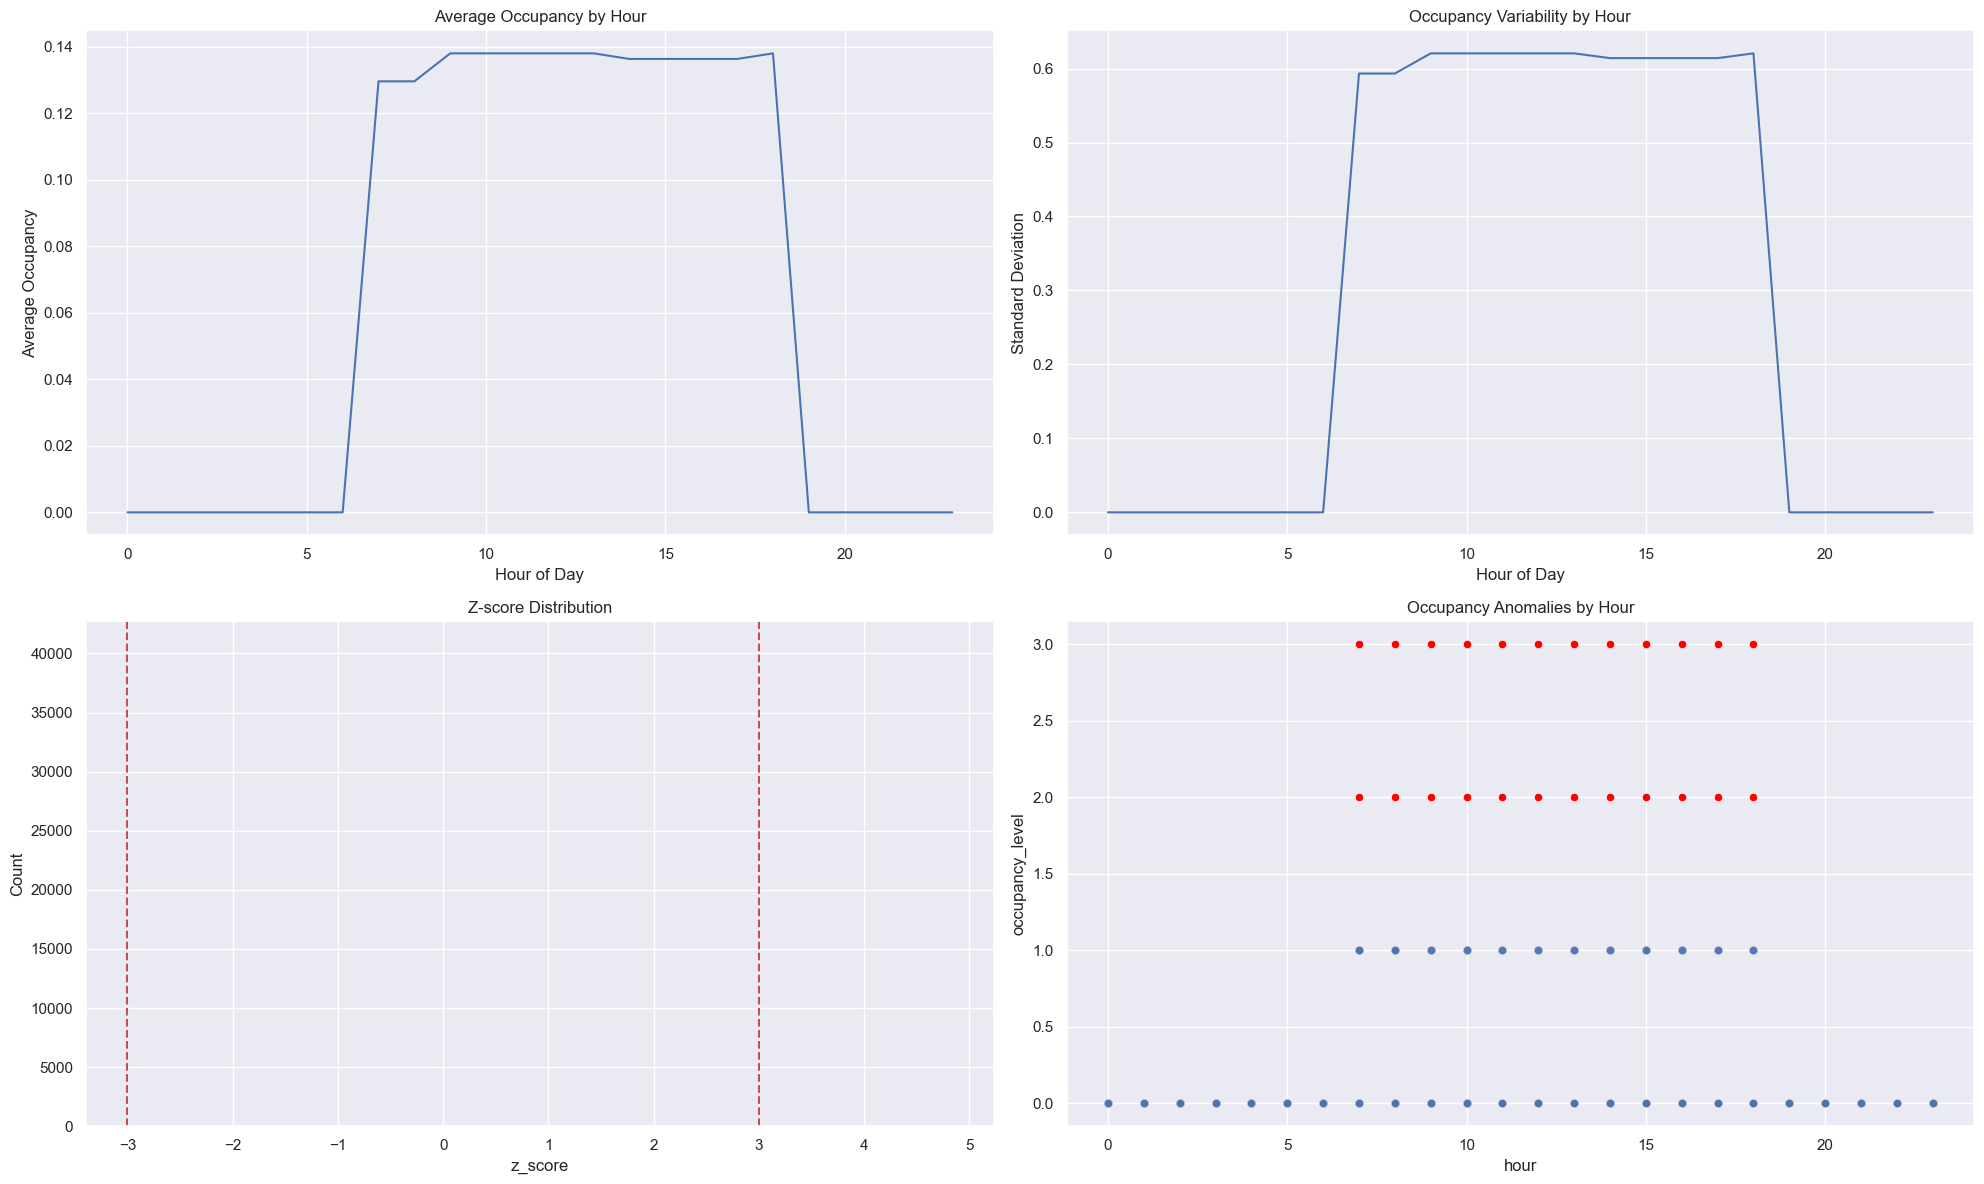


Anomaly Summary:
Total anomalies found: 3840
Percentage of anomalies: 2.24%

Example anomalies:
                    datetime  hour  occupancy_level   z_score   tipo  \
22 2025-01-31 07:00:00+00:00     7                3  4.838473  BLAVA   
23 2025-01-31 07:00:00+00:00     7                3  4.838473  BLAVA   
26 2025-01-31 07:00:00+00:00     7                3  4.838473  BLAVA   
52 2025-01-31 07:00:00+00:00     7                3  4.838473  BLAVA   
95 2025-01-31 07:00:00+00:00     7                3  4.838473  BLAVA   

                           tramo  
22  PAS  SOTA MURALLA, FRENTE 11  
23      CARRER  MUNTANER, FTE, 3  
26   PAS  SOTA MURALLA, frente 9  
52          CARRER  CORSEGA, 441  
95    PASSEIG  FABRA I PUIG, 109  

Anomaly distribution by hour:
hour
7     300
8     300
9     324
10    324
11    324
12    324
13    324
14    324
15    324
16    324
17    324
18    324
Name: count, dtype: int64

Anomaly distribution by parking type:
tipo
BLAVA    3840
Name: count, dtype: 

In [22]:
analyze_extreme_values(merged_data)
analyze_temporal_anomalies(merged_data)

In [32]:
%pip install plotly
%pip install plotly nbformat>=4.2.0


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
zsh:1: 4.2.0 not found
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Cell: Interactive Anomaly Visualizations
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def prepare_anomaly_data(data):
    """Prepare data by calculating z-scores and identifying anomalies."""
    # Create a clean copy of the data with unique column names
    clean_data = data.copy()
    
    # Rename duplicate columns if they exist
    if clean_data.columns.duplicated().any():
        clean_data.columns = pd.Index([f'{col}_{i}' if clean_data.columns[:i].tolist().count(col) > 0 
                                     else col for i, col in enumerate(clean_data.columns)])
    
    # Group by time components
    hourly_stats = clean_data.groupby('hour')['occupancy_level'].agg(['mean', 'std']).reset_index()
    
    # Merge stats back to original data
    data_with_stats = clean_data.merge(hourly_stats, on='hour', suffixes=('', '_hour'))
    
    # Calculate z-scores
    data_with_stats['z_score'] = (
        (data_with_stats['occupancy_level'] - data_with_stats['mean']) / 
        data_with_stats['std'].clip(lower=1e-10)  # Avoid division by zero
    )
    
    # Identify anomalies
    anomalies = data_with_stats[abs(data_with_stats['z_score']) > 3].copy()
    
    # Print column names for debugging
    print("Columns after preparation:")
    print(data_with_stats.columns.tolist())
    
    return data_with_stats, anomalies

def create_interactive_visualizations(data):
    """Create interactive visualizations for anomaly analysis."""
    # Prepare data with z-scores and anomalies
    data_with_stats, anomalies = prepare_anomaly_data(data)
    
    # 1. Interactive Time Series with Anomalies
    fig1 = px.scatter(data_with_stats, 
                     x='hour', 
                     y='occupancy_level',
                     color='tipo',
                     opacity=0.6,
                     title='Occupancy Levels by Hour (Hover for details)')
    
    # Add anomalies as a separate trace
    if len(anomalies) > 0:
        fig1.add_trace(
            go.Scatter(
                x=anomalies['hour'],
                y=anomalies['occupancy_level'],
                mode='markers',
                name='Anomalies',
                marker=dict(color='red', size=10),
                hovertemplate="Hour: %{x}<br>" +
                             "Occupancy: %{y}<br>" +
                             "<extra>Anomaly</extra>"
            )
        )
    
    # 2. Interactive Heatmap of Anomalies
    anomaly_pivot = pd.pivot_table(
        data_with_stats,
        values='occupancy_level',
        index='hour',
        columns='day_of_week',
        aggfunc='mean',
        fill_value=0
    )
    
    fig2 = go.Figure(data=go.Heatmap(
        z=anomaly_pivot.values,
        x=anomaly_pivot.columns,
        y=anomaly_pivot.index,
        colorscale='Viridis',
        hoverongaps=False,
        hovertemplate="Day: %{x}<br>" +
                     "Hour: %{y}<br>" +
                     "Average Occupancy: %{z:.2f}<br>" +
                     "<extra></extra>"
    ))
    
    fig2.update_layout(
        title='Occupancy Distribution Heatmap',
        xaxis_title='Day of Week',
        yaxis_title='Hour of Day'
    )
    
    # 3. Interactive Box Plots
    fig3 = make_subplots(rows=1, cols=2,
                        subplot_titles=('Occupancy Distribution by Hour',
                                      'Z-Score Distribution by Hour'))
    
    fig3.add_trace(
        go.Box(x=data_with_stats['hour'], 
               y=data_with_stats['occupancy_level'],
               name='Normal',
               boxpoints='outliers'),
        row=1, col=1
    )
    
    fig3.add_trace(
        go.Box(x=data_with_stats['hour'],
               y=data_with_stats['z_score'],
               name='Z-scores',
               boxpoints='outliers'),
        row=1, col=2
    )
    
    fig3.update_layout(height=600, showlegend=False)
    
    # Print summary statistics
    print("\nAnomaly Analysis Summary:")
    print(f"Total data points: {len(data_with_stats)}")
    print(f"Anomalies detected: {len(anomalies)}")
    print(f"Anomaly percentage: {(len(anomalies) / len(data_with_stats)) * 100:.2f}%")
    
    return fig1, fig2, fig3

# Run interactive visualizations
figs = create_interactive_visualizations(merged_data)

# Display all figures
for i, fig in enumerate(figs, 1):
    if fig is not None:
        display(fig)

NameError: name 'merged_data' is not defined